# 03 — Final combined RQ3: effect of history length

**RQ3:** How does history length affect VLM classification performance?

This notebook performs parallel repeated-measures analyses for:

1. **Bag-level Accuracy**
2. **Bag-level Macro-F1**

The combined clean freeze contains 25 bags (15 HuRoN, 3 PAL, and 7 CrowdBot), 34,912 frames per configuration, 3 models, 2 approaches, and 16 histories (H02–H32), producing 96 clean configuration files.

For each outcome, one Friedman test compares the 16 histories within every fixed model–approach combination: 3 models × 2 approaches = **6 tests per outcome**. Holm correction is applied across those six omnibus tests separately for Accuracy and Macro-F1. Only a Holm-significant Friedman result triggers the 120 paired history comparisons. Those Wilcoxon signed-rank tests are Holm-corrected within their model–approach family.

The summary tiers are based exclusively on **Holm-significant Wilcoxon wins**:

- **First better:** history/histories with the largest number of significant wins.
- **Second better:** the next distinct significant-win count.
- **Third better:** the third distinct significant-win count.
- **All significant winning histories:** guarantees that every history with at least one significant win is reported, including any lower tiers.

A non-significant comparison is always labeled `No difference` and can never place a history in a better tier. The saved `predicted_label` is the authoritative classification output; probability argmax is not substituted.

In [1]:
from pathlib import Path
from itertools import combinations
import warnings

import numpy as np
import pandas as pd
from IPython.display import display
from scipy.stats import friedmanchisquare, rankdata, wilcoxon
from sklearn.metrics import accuracy_score, f1_score

HERE = Path.cwd().resolve()
ROOT = next((p for p in [HERE, *HERE.parents] if (p / "Combined" / "clean").is_dir()), HERE)
CLEAN, OUT = ROOT / "Combined" / "clean", ROOT / "Combined" / "rq3"
TEX = OUT / "latex"
OUT.mkdir(parents=True, exist_ok=True)
TEX.mkdir(parents=True, exist_ok=True)

MODELS = ["qwen", "internvl", "llava"]
APPROACHES = ["appfr", "appod"]
HISTORIES = [f"H{h:02d}" for h in range(2, 33, 2)]
LABELS = ["safe", "potentially_unsafe", "unsafe"]
CASE_STUDIES = ["huron", "pal", "crowdbot"]
OUTCOMES = ["accuracy", "macro_f1"]

MODEL_NAMES = {"qwen": "Qwen", "internvl": "InternVL", "llava": "LLaVA"}
APPROACH_NAMES = {"appfr": "AppFr", "appod": "AppOd"}
OUTCOME_NAMES = {"accuracy": "Accuracy", "macro_f1": "Macro-F1"}
EXPECTED_ROWS, EXPECTED_BAGS = 34_912, 25
EXPECTED_CASE_BAGS = {"huron": 15, "pal": 3, "crowdbot": 7}
EXPECTED_CASE_ROWS = {"huron": 16_862, "pal": 9_249, "crowdbot": 8_801}
ALPHA = 0.05
EXPORTED = []

def clean_file(model, approach, history):
    candidates = [
        CLEAN / model / f"{model}_{approach}_{history.lower()}.csv",
        CLEAN / model / approach / f"{history}.csv",
    ]
    for path in candidates:
        if path.is_file():
            return path
    raise FileNotFoundError("Missing combined clean file; tried: " + ", ".join(map(str, candidates)))

def normalize_label(series):
    return (series.astype(str).str.strip().str.lower()
            .str.replace("-", "_", regex=False).str.replace(" ", "_", regex=False))

def class_recall(y_true, y_pred, label):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    mask = y_true == label
    return float((y_pred[mask] == label).mean()) if mask.any() else np.nan

def metric_record(df):
    y_true, y_pred = df["ground_truth"].to_numpy(), df["predicted_label"].to_numpy()
    recalls = {label: class_recall(y_true, y_pred, label) for label in LABELS}
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": float(np.nanmean(list(recalls.values()))),
        "macro_f1": f1_score(y_true, y_pred, labels=LABELS, average="macro", zero_division=0),
        **{f"recall_{label}": value for label, value in recalls.items()},
    }

def holm_adjust(p_values):
    p = np.asarray(p_values, float)
    adjusted = np.full(len(p), np.nan)
    valid = np.flatnonzero(np.isfinite(p))
    order = valid[np.argsort(p[valid])]
    running = 0.0
    for rank, index in enumerate(order):
        running = max(running, (len(order) - rank) * p[index])
        adjusted[index] = min(running, 1.0)
    return adjusted

def safe_friedman(matrix):
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            result = friedmanchisquare(*[matrix[column] for column in matrix.columns])
        statistic, p_value = float(result.statistic), float(result.pvalue)
        return (statistic, p_value) if np.isfinite(statistic + p_value) else (0.0, 1.0)
    except ValueError:
        return 0.0, 1.0

def safe_wilcoxon(x, y):
    x, y = np.asarray(x, float), np.asarray(y, float)
    valid = np.isfinite(x) & np.isfinite(y)
    x, y = x[valid], y[valid]
    if np.allclose(x, y):
        return 0.0, 1.0
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        result = wilcoxon(x, y, zero_method="wilcox", alternative="two-sided", method="auto")
    return float(result.statistic), float(result.pvalue)

def rank_biserial(x, y):
    difference = np.asarray(x, float) - np.asarray(y, float)
    difference = difference[np.isfinite(difference) & (difference != 0)]
    if not len(difference):
        return 0.0
    ranks = rankdata(np.abs(difference), method="average")
    return float((ranks[difference > 0].sum() - ranks[difference < 0].sum()) / ranks.sum())

def p_report(p):
    return "NA" if not np.isfinite(p) else "<0.001" if p < 0.001 else f"{p:.3f}"

def format_win_tier(win_counts, tier_index):
    levels = sorted(win_counts.unique(), reverse=True)
    if tier_index >= len(levels):
        return "—"
    wins = levels[tier_index]
    histories = sorted(win_counts[win_counts == wins].index, key=lambda h: int(h[1:]))
    return f"{', '.join(histories)} ({wins}{' each' if len(histories) > 1 else ''})"

def format_all_winners(win_counts):
    levels = sorted(win_counts.unique(), reverse=True)
    return "; ".join(format_win_tier(win_counts, i) for i in range(len(levels))) if levels else "—"

def export(df, name, caption, index=False):
    df.to_csv(OUT / f"{name}.csv", index=index)
    kwargs = dict(
        index=index, escape=True, na_rep="--", float_format=lambda x: f"{x:.6g}",
        caption=caption, label=f"tab:{name.replace('_', '-')}",
        multicolumn=True, multicolumn_format="c",
    )
    if len(df) > 80:
        kwargs["longtable"] = True
    else:
        kwargs["position"] = "tbp"
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", FutureWarning)
        latex = df.to_latex(**kwargs)
    (TEX / f"{name}.tex").write_text(latex, encoding="utf-8")
    if name not in EXPORTED:
        EXPORTED.append(name)

print("Input:", CLEAN)
print("Output:", OUT)
print("Design: 3 models × 2 approaches × 16 histories = 96 files")

Input: <HOME>/VLM_EW_Robot_Safety_DT/Analysis/Combined/clean
Output: <HOME>/VLM_EW_Robot_Safety_DT/Analysis/Combined/rq3
Design: 3 models × 2 approaches × 16 histories = 96 files


## 1. Validate the combined clean freeze and calculate metrics

Every configuration must contain the same 25 bags, frame identities, and ground truth. Accuracy and Macro-F1 are calculated from the saved prediction labels both across all frames (descriptive) and within each bag (inferential input). Macro-F1 uses the fixed three-class label set with `zero_division=0`.

In [2]:
REQUIRED = {"case_study", "global_bag_id", "frame_id", "ground_truth", "predicted_label"}
validation_rows, pooled_rows, bag_rows = [], [], []
reference_identity = reference_bags = reference_frame = None

for model in MODELS:
    for approach in APPROACHES:
        for history in HISTORIES:
            path = clean_file(model, approach, history)
            df = pd.read_csv(path, low_memory=False)
            name = f"{model} {approach} {history}"
            assert REQUIRED.issubset(df), f"{name}: missing {sorted(REQUIRED - set(df))}"
            for column in ["case_study", "ground_truth", "predicted_label"]:
                df[column] = normalize_label(df[column])
            df["global_bag_id"] = df["global_bag_id"].astype(str)

            assert len(df) == EXPECTED_ROWS, f"{name}: wrong row count"
            assert df["global_bag_id"].nunique() == EXPECTED_BAGS, f"{name}: wrong bag count"
            assert not df[["global_bag_id", "frame_id"]].isna().any().any(), f"{name}: missing identity"
            assert not df.duplicated(["global_bag_id", "frame_id"]).any(), f"{name}: duplicate frame"
            assert set(df["ground_truth"]) <= set(LABELS), f"{name}: invalid ground truth"
            assert set(df["predicted_label"]) <= set(LABELS), f"{name}: invalid prediction"

            case_bags = df.groupby("case_study")["global_bag_id"].nunique().astype(int).to_dict()
            case_rows = df.groupby("case_study").size().astype(int).to_dict()
            assert case_bags == EXPECTED_CASE_BAGS, f"{name}: case bags {case_bags}"
            assert case_rows == EXPECTED_CASE_ROWS, f"{name}: case rows {case_rows}"

            identity = (df[["global_bag_id", "frame_id", "ground_truth"]].astype(str)
                        .sort_values(["global_bag_id", "frame_id"]).reset_index(drop=True))
            bags = set(df["global_bag_id"])
            if reference_identity is None:
                reference_identity, reference_bags = identity, bags
                reference_frame = df[["case_study", "global_bag_id", "ground_truth"]].copy()
            else:
                assert bags == reference_bags and identity.equals(reference_identity), f"{name}: identity mismatch"

            key = {"model": model, "approach": approach,
                   "history": history, "history_frames": int(history[1:])}
            pooled_rows.append({**key, "frames": len(df), "bags": EXPECTED_BAGS,
                                **metric_record(df)})
            for (case_study, bag_id), bag in df.groupby(["case_study", "global_bag_id"], sort=True):
                bag_rows.append({**key, "case_study": case_study, "global_bag_id": bag_id,
                                 "frames": len(bag), **metric_record(bag)})
            validation_rows.append({**key, "input_file": str(path.relative_to(ROOT)),
                                    "rows": len(df), "bags": EXPECTED_BAGS})

validation = pd.DataFrame(validation_rows)
pooled_metrics = pd.DataFrame(pooled_rows)
bag_metrics = pd.DataFrame(bag_rows)
distribution = (pd.crosstab(reference_frame["case_study"], reference_frame["ground_truth"])
                .reindex(index=CASE_STUDIES, columns=LABELS, fill_value=0).astype(int))
distribution["total_frames"] = distribution.sum(axis=1)

assert len(validation) == len(pooled_metrics) == 96
assert len(bag_metrics) == 96 * EXPECTED_BAGS == 2_400
assert validation["rows"].eq(EXPECTED_ROWS).all() and validation["bags"].eq(EXPECTED_BAGS).all()

display(distribution)
display(validation.groupby(["model", "approach"]).agg(
    clean_files=("input_file", "size"), rows_per_file=("rows", "first"),
    bags_per_file=("bags", "first")))
print(f"Ready: {len(validation)} files and {len(bag_metrics):,} bag-level observations.")

ground_truth,safe,potentially_unsafe,unsafe,total_frames
case_study,,,,
huron,15273,1378,211,16862
pal,5518,2769,962,9249
crowdbot,4205,4350,246,8801


clean_files  rows_per_file  bags_per_file
model    approach                                           
internvl appfr              16          34912             25
         appod              16          34912             25
llava    appfr              16          34912             25
         appod              16          34912             25
qwen     appfr              16          34912             25
         appod              16          34912             25

Ready: 96 files and 2,400 bag-level observations.


## 2. Shared Accuracy and Macro-F1 analysis

The function below applies exactly the same workflow to both outcomes. The six omnibus tests are corrected within the outcome. Pairwise tests are gated by the corrected omnibus result, and the `significant_better_history` field is populated only when the pairwise Holm p-value is below 0.05.

In [3]:
PAIRWISE_COLUMNS = [
    "metric", "model", "approach", "history_1", "history_2",
    "n_pairs", "nonzero_pairs", "friedman_holm_p",
    "median_difference_h1_minus_h2", "mean_difference_h1_minus_h2",
    "wilcoxon_statistic", "raw_p", "holm_p",
    "rank_biserial_h1_minus_h2", "significant_holm",
    "significant_better_history",
]

def run_history_analysis(metric):
    label = OUTCOME_NAMES[metric]
    matrices, profile_rows, omnibus_rows = {}, [], []

    for model in MODELS:
        for approach in APPROACHES:
            part = bag_metrics[(bag_metrics["model"] == model) &
                               (bag_metrics["approach"] == approach)]
            matrix = (part.pivot(index=["case_study", "global_bag_id"],
                                 columns="history", values=metric)
                      .reindex(columns=HISTORIES))
            assert matrix.shape == (EXPECTED_BAGS, len(HISTORIES))
            assert not matrix.isna().any().any()
            matrices[(model, approach)] = matrix
            ranks = matrix.rank(axis=1, ascending=False, method="average")

            for history in HISTORIES:
                values = matrix[history]
                pooled_value = pooled_metrics.loc[
                    (pooled_metrics["model"] == model) &
                    (pooled_metrics["approach"] == approach) &
                    (pooled_metrics["history"] == history), metric
                ].iloc[0]
                case_medians = part[part["history"] == history].groupby("case_study")[metric].median()
                q1, q3 = values.quantile([0.25, 0.75])
                profile_rows.append({
                    "metric": metric, "model": model, "approach": approach,
                    "history": history, "history_frames": int(history[1:]),
                    "bags": len(values), "median_bag_value": values.median(),
                    "mean_bag_value": values.mean(), "q1_bag_value": q1,
                    "q3_bag_value": q3, "iqr_bag_value": q3 - q1,
                    "minimum_bag_value": values.min(), "maximum_bag_value": values.max(),
                    "average_rank": ranks[history].mean(), "pooled_frame_value": pooled_value,
                    **{f"{case}_median_bag_value": case_medians.get(case, np.nan)
                       for case in CASE_STUDIES},
                })

            statistic, raw_p = safe_friedman(matrix)
            omnibus_rows.append({
                "metric": metric, "model": model, "approach": approach,
                "bags": len(matrix), "histories": len(HISTORIES),
                "degrees_of_freedom": len(HISTORIES) - 1,
                "friedman_chi2": statistic, "raw_p": raw_p,
                "kendalls_w": statistic / (len(matrix) * (len(HISTORIES) - 1)),
            })

    profiles = pd.DataFrame(profile_rows)
    friedman = pd.DataFrame(omnibus_rows)
    friedman["holm_p"] = holm_adjust(friedman["raw_p"])
    friedman["significant_raw"] = friedman["raw_p"] < ALPHA
    friedman["significant_holm"] = friedman["holm_p"] < ALPHA

    pairwise_rows = []
    for omnibus in friedman.itertuples(index=False):
        if not omnibus.significant_holm:
            continue
        matrix = matrices[(omnibus.model, omnibus.approach)]
        family = []
        for history_1, history_2 in combinations(HISTORIES, 2):
            x, y = matrix[history_1], matrix[history_2]
            difference = x - y
            statistic, raw_p = safe_wilcoxon(x, y)
            effect = rank_biserial(x, y)
            family.append({
                "metric": metric, "model": omnibus.model, "approach": omnibus.approach,
                "history_1": history_1, "history_2": history_2,
                "n_pairs": len(matrix), "nonzero_pairs": int(difference.ne(0).sum()),
                "friedman_holm_p": omnibus.holm_p,
                "median_difference_h1_minus_h2": difference.median(),
                "mean_difference_h1_minus_h2": difference.mean(),
                "wilcoxon_statistic": statistic, "raw_p": raw_p,
                "rank_biserial_h1_minus_h2": effect,
                "directional_history": history_1 if effect > 0 else history_2 if effect < 0 else "tie",
            })

        for row, adjusted_p in zip(family, holm_adjust([row["raw_p"] for row in family])):
            row["holm_p"] = adjusted_p
            row["significant_holm"] = bool(adjusted_p < ALPHA)
            row["significant_better_history"] = (
                row["directional_history"] if adjusted_p < ALPHA else "No difference"
            )
            row.pop("directional_history")
        pairwise_rows.extend(family)

    pairwise = pd.DataFrame(pairwise_rows, columns=PAIRWISE_COLUMNS)
    significant = pairwise.loc[
        pairwise["significant_holm"].fillna(False).astype(bool)
    ].copy()

    if len(pairwise):
        assert pairwise.loc[pairwise["significant_holm"],
                            "significant_better_history"].isin(HISTORIES).all()
        assert pairwise.loc[~pairwise["significant_holm"],
                            "significant_better_history"].eq("No difference").all()

    summary_rows, win_rows = [], []
    for omnibus in friedman.itertuples(index=False):
        family = pairwise[(pairwise["model"] == omnibus.model) &
                          (pairwise["approach"] == omnibus.approach)]
        wins = significant[(significant["model"] == omnibus.model) &
                           (significant["approach"] == omnibus.approach)]
        win_counts = wins["significant_better_history"].value_counts()
        assert int(win_counts.sum()) == len(wins)

        for history, number_of_wins in win_counts.items():
            involving = wins[(wins["history_1"] == history) | (wins["history_2"] == history)]
            win_rows.append({
                "metric": metric, "model": omnibus.model, "approach": omnibus.approach,
                "history": history, "significant_wins": int(number_of_wins),
                "significant_losses": int(len(involving) - number_of_wins),
                "win_tier": sorted(win_counts.unique(), reverse=True).index(number_of_wins) + 1,
            })

        strict = win_counts[win_counts == len(HISTORIES) - 1].index.tolist()
        summary_rows.append({
            "metric": metric, "model": omnibus.model, "approach": omnibus.approach,
            "bags": omnibus.bags, "histories": omnibus.histories,
            "friedman_chi2": omnibus.friedman_chi2, "raw_p": omnibus.raw_p,
            "holm_p": omnibus.holm_p, "holm_p_report": p_report(omnibus.holm_p),
            "kendalls_w": omnibus.kendalls_w,
            "omnibus_significant_holm": omnibus.significant_holm,
            "pairwise_tests_performed": len(family),
            "significant_pairwise_tests": len(wins),
            "significant_pairs": (f"{len(wins)}/{len(family)}" if len(family)
                                    else "Not performed"),
            "histories_with_significant_wins": len(win_counts),
            "strict_significant_winner": strict[0] if len(strict) == 1 else "—",
            "first_better": format_win_tier(win_counts, 0),
            "second_better": format_win_tier(win_counts, 1),
            "third_better": format_win_tier(win_counts, 2),
            "all_significant_winning_histories": format_all_winners(win_counts),
        })

    summary = pd.DataFrame(summary_rows)
    win_counts = pd.DataFrame(win_rows, columns=[
        "metric", "model", "approach", "history",
        "significant_wins", "significant_losses", "win_tier",
    ])
    publication = pd.DataFrame({
        "Metric": label,
        "Model": summary["model"].map(MODEL_NAMES),
        "Approach": summary["approach"].map(APPROACH_NAMES),
        "Bags": summary["bags"].astype(int),
        "Histories": summary["histories"].astype(int),
        "Friedman chi2": summary["friedman_chi2"].round(3),
        "Holm p-value": summary["holm_p_report"],
        "Kendall's W": summary["kendalls_w"].round(3),
        "Significant pairs": summary["significant_pairs"],
        "Strict winner": summary["strict_significant_winner"],
        "First better": summary["first_better"],
        "Second better": summary["second_better"],
        "Third better": summary["third_better"],
        "All significant winning histories": summary["all_significant_winning_histories"],
    })

    assert len(profiles) == 96 and len(friedman) == len(summary) == len(publication) == 6
    assert len(pairwise) == 120 * int(friedman["significant_holm"].sum())
    return {
        "profiles": profiles, "friedman": friedman, "pairwise": pairwise,
        "significant": significant, "win_counts": win_counts,
        "summary_detailed": summary, "summary": publication,
    }

## 3. Accuracy results

The following table summarizes the six Accuracy Friedman tests and ranks histories only by Holm-significant Accuracy wins. `Not performed` means the corrected omnibus test was not significant; `0/120` means post-hoc testing was performed but no pair survived Holm correction.

In [4]:
accuracy_results = run_history_analysis("accuracy")

rq3_accuracy_profiles = accuracy_results["profiles"]
rq3_accuracy_friedman = accuracy_results["friedman"]
rq3_accuracy_pairwise = accuracy_results["pairwise"]
rq3_accuracy_pairwise_significant = accuracy_results["significant"]
rq3_accuracy_significant_win_counts = accuracy_results["win_counts"]
rq3_accuracy_summary_detailed = accuracy_results["summary_detailed"]
rq3_accuracy_summary = accuracy_results["summary"]

display(rq3_accuracy_summary)
display(rq3_accuracy_significant_win_counts)
print("Accuracy Friedman tests:", len(rq3_accuracy_friedman))
print("Accuracy gated Wilcoxon tests:", len(rq3_accuracy_pairwise))
print("Accuracy significant Wilcoxon tests:", len(rq3_accuracy_pairwise_significant))

,Metric,Model,Approach,Bags,Histories,Friedman chi2,Holm p-value,Kendall's W,Significant pairs,Strict winner,First better,Second better,Third better,All significant winning histories
0,Accuracy,Qwen,AppFr,25,16,46.832,<0.001,0.125,0/120,—,—,—,—,—
1,Accuracy,Qwen,AppOd,25,16,105.041,<0.001,0.280,14/120,—,H32 (4),H30 (3),"H26, H28 (2 each)","H32 (4); H30 (3); H26, H28 (2 each); H06, H14,..."
2,Accuracy,InternVL,AppFr,25,16,117.504,<0.001,0.313,53/120,—,"H02, H14, H16 (12 each)",H04 (11),H06 (3),"H02, H14, H16 (12 each); H04 (11); H06 (3); H0..."
3,Accuracy,InternVL,AppOd,25,16,78.461,<0.001,0.209,26/120,—,H14 (5),"H02, H22 (4 each)",H30 (3),"H14 (5); H02, H22 (4 each); H30 (3); H04, H16,..."
4,Accuracy,LLaVA,AppFr,25,16,67.202,<0.001,0.179,4/120,—,"H18, H20 (2 each)",—,—,"H18, H20 (2 each)"
5,Accuracy,LLaVA,AppOd,25,16,49.213,<0.001,0.131,1/120,—,H16 (1),—,—,H16 (1)


,metric,model,approach,history,significant_wins,significant_losses,win_tier
0,accuracy,qwen,appod,H32,4,0,1
1,accuracy,qwen,appod,H30,3,0,2
2,accuracy,qwen,appod,H28,2,0,3
3,accuracy,qwen,appod,H26,2,0,3
4,accuracy,qwen,appod,H06,1,0,4
5,accuracy,qwen,appod,H24,1,0,4
6,accuracy,qwen,appod,H14,1,0,4
7,accuracy,internvl,appfr,H02,12,0,1
8,accuracy,internvl,appfr,H16,12,0,1
9,accuracy,internvl,appfr,H14,12,0,1


Accuracy Friedman tests: 6
Accuracy gated Wilcoxon tests: 720
Accuracy significant Wilcoxon tests: 98


## 4. Macro-F1 results

The identical analysis is repeated for bag-level three-class Macro-F1. The better tiers again contain only histories that won at least one Holm-significant Wilcoxon comparison.

In [5]:
macro_f1_results = run_history_analysis("macro_f1")

rq3_macro_f1_profiles = macro_f1_results["profiles"]
rq3_macro_f1_friedman = macro_f1_results["friedman"]
rq3_macro_f1_pairwise = macro_f1_results["pairwise"]
rq3_macro_f1_pairwise_significant = macro_f1_results["significant"]
rq3_macro_f1_significant_win_counts = macro_f1_results["win_counts"]
rq3_macro_f1_summary_detailed = macro_f1_results["summary_detailed"]
rq3_macro_f1_summary = macro_f1_results["summary"]

display(rq3_macro_f1_summary)
display(rq3_macro_f1_significant_win_counts)
print("Macro-F1 Friedman tests:", len(rq3_macro_f1_friedman))
print("Macro-F1 gated Wilcoxon tests:", len(rq3_macro_f1_pairwise))
print("Macro-F1 significant Wilcoxon tests:", len(rq3_macro_f1_pairwise_significant))

,Metric,Model,Approach,Bags,Histories,Friedman chi2,Holm p-value,Kendall's W,Significant pairs,Strict winner,First better,Second better,Third better,All significant winning histories
0,Macro-F1,Qwen,AppFr,25,16,22.123,0.418,0.059,Not performed,—,—,—,—,—
1,Macro-F1,Qwen,AppOd,25,16,19.353,0.595,0.052,Not performed,—,—,—,—,—
2,Macro-F1,InternVL,AppFr,25,16,143.629,<0.001,0.383,33/120,—,H02 (12),H14 (7),H06 (5),H02 (12); H14 (7); H06 (5); H04 (4); H16 (3); ...
3,Macro-F1,InternVL,AppOd,25,16,82.977,<0.001,0.221,20/120,—,"H02, H04, H14, H16, H18, H20, H22, H24, H30 (2...","H10, H12 (1 each)",—,"H02, H04, H14, H16, H18, H20, H22, H24, H30 (2..."
4,Macro-F1,LLaVA,AppFr,25,16,17.044,0.625,0.045,Not performed,—,—,—,—,—
5,Macro-F1,LLaVA,AppOd,25,16,17.108,0.625,0.046,Not performed,—,—,—,—,—


,metric,model,approach,history,significant_wins,significant_losses,win_tier
0,macro_f1,internvl,appfr,H02,12,0,1
1,macro_f1,internvl,appfr,H14,7,0,2
2,macro_f1,internvl,appfr,H06,5,1,3
3,macro_f1,internvl,appfr,H04,4,0,4
4,macro_f1,internvl,appfr,H16,3,0,5
5,macro_f1,internvl,appfr,H08,2,1,6
6,macro_f1,internvl,appod,H02,2,0,1
7,macro_f1,internvl,appod,H04,2,0,1
8,macro_f1,internvl,appod,H14,2,0,1
9,macro_f1,internvl,appod,H16,2,0,1


Macro-F1 Friedman tests: 6
Macro-F1 gated Wilcoxon tests: 240
Macro-F1 significant Wilcoxon tests: 53


## 5. Combined summary, exports, and verification

The combined summary places Accuracy and Macro-F1 in one 12-row publication table. Separate CSV and LaTeX files preserve every Friedman result, every performed Wilcoxon test, the significant-only comparisons, all history win counts, and the final summaries.

In [6]:
rq3_combined_summary = pd.concat(
    [rq3_accuracy_summary, rq3_macro_f1_summary], ignore_index=True
)
rq3_combined_summary_detailed = pd.concat(
    [rq3_accuracy_summary_detailed, rq3_macro_f1_summary_detailed], ignore_index=True
)
rq3_all_significant_history_wins = pd.concat(
    [rq3_accuracy_significant_win_counts, rq3_macro_f1_significant_win_counts],
    ignore_index=True,
)

display(rq3_combined_summary)

shared_tables = {
    "rq3_clean_validation": (validation, "Validation of the 96 combined RQ3 inputs."),
    "rq3_pooled_metrics": (pooled_metrics, "Descriptive pooled-frame performance metrics."),
    "rq3_bag_metrics": (bag_metrics, "Bag-level metrics used for RQ3 inference."),
}
metric_tables = {
    "rq3_accuracy_history_profiles": (rq3_accuracy_profiles, "Accuracy history profiles."),
    "rq3_accuracy_friedman": (rq3_accuracy_friedman, "Accuracy Friedman tests."),
    "rq3_accuracy_pairwise_wilcoxon": (rq3_accuracy_pairwise, "Accuracy gated Wilcoxon-Holm tests."),
    "rq3_accuracy_pairwise_holm_significant": (rq3_accuracy_pairwise_significant, "Significant Accuracy Wilcoxon-Holm tests."),
    "rq3_accuracy_significant_history_wins": (rq3_accuracy_significant_win_counts, "All histories with significant Accuracy wins."),
    "rq3_accuracy_summary_detailed": (rq3_accuracy_summary_detailed, "Detailed Accuracy summary."),
    "rq3_accuracy_summary": (rq3_accuracy_summary, "Publication Accuracy summary."),
    "rq3_macro_f1_history_profiles": (rq3_macro_f1_profiles, "Macro-F1 history profiles."),
    "rq3_macro_f1_friedman": (rq3_macro_f1_friedman, "Macro-F1 Friedman tests."),
    "rq3_macro_f1_pairwise_wilcoxon": (rq3_macro_f1_pairwise, "Macro-F1 gated Wilcoxon-Holm tests."),
    "rq3_macro_f1_pairwise_holm_significant": (rq3_macro_f1_pairwise_significant, "Significant Macro-F1 Wilcoxon-Holm tests."),
    "rq3_macro_f1_significant_history_wins": (rq3_macro_f1_significant_win_counts, "All histories with significant Macro-F1 wins."),
    "rq3_macro_f1_summary_detailed": (rq3_macro_f1_summary_detailed, "Detailed Macro-F1 summary."),
    "rq3_macro_f1_summary": (rq3_macro_f1_summary, "Publication Macro-F1 summary."),
    "rq3_all_significant_history_wins": (rq3_all_significant_history_wins, "All significant history wins for both outcomes."),
    "rq3_combined_summary_detailed": (rq3_combined_summary_detailed, "Detailed combined Accuracy and Macro-F1 summary."),
    "rq3_combined_summary": (rq3_combined_summary, "Combined Accuracy and Macro-F1 publication summary."),
}

for name, (table, caption) in {**shared_tables, **metric_tables}.items():
    export(table, name, caption)

manifest_names = sorted(set(EXPORTED) | {"rq3_output_manifest"})
manifest = pd.DataFrame([{
    "table": name, "csv": str(OUT / f"{name}.csv"),
    "latex": str(TEX / f"{name}.tex"), "format": "CSV + LaTeX",
} for name in manifest_names])
export(manifest, "rq3_output_manifest", "Manifest of final combined RQ3 outputs.")

missing_csv = [name for name in manifest_names if not (OUT / f"{name}.csv").is_file()]
missing_tex = [name for name in manifest_names if not (TEX / f"{name}.tex").is_file()]
assert not missing_csv and not missing_tex, (missing_csv, missing_tex)
assert len(validation) == len(pooled_metrics) == 96 and len(bag_metrics) == 2_400
assert len(rq3_accuracy_friedman) == len(rq3_macro_f1_friedman) == 6
assert len(rq3_accuracy_summary) == len(rq3_macro_f1_summary) == 6
assert len(rq3_combined_summary) == 12
assert len(rq3_accuracy_pairwise) == 120 * int(rq3_accuracy_friedman["significant_holm"].sum())
assert len(rq3_macro_f1_pairwise) == 120 * int(rq3_macro_f1_friedman["significant_holm"].sum())

print("FINAL COMBINED RQ3 COMPLETE")
print("Accuracy: Friedman =", len(rq3_accuracy_friedman),
      "; gated Wilcoxon =", len(rq3_accuracy_pairwise),
      "; significant pairs =", len(rq3_accuracy_pairwise_significant))
print("Macro-F1: Friedman =", len(rq3_macro_f1_friedman),
      "; gated Wilcoxon =", len(rq3_macro_f1_pairwise),
      "; significant pairs =", len(rq3_macro_f1_pairwise_significant))
print("Output folder:", OUT)
display(manifest)

,Metric,Model,Approach,Bags,Histories,Friedman chi2,Holm p-value,Kendall's W,Significant pairs,Strict winner,First better,Second better,Third better,All significant winning histories
0,Accuracy,Qwen,AppFr,25,16,46.832,<0.001,0.125,0/120,—,—,—,—,—
1,Accuracy,Qwen,AppOd,25,16,105.041,<0.001,0.280,14/120,—,H32 (4),H30 (3),"H26, H28 (2 each)","H32 (4); H30 (3); H26, H28 (2 each); H06, H14,..."
2,Accuracy,InternVL,AppFr,25,16,117.504,<0.001,0.313,53/120,—,"H02, H14, H16 (12 each)",H04 (11),H06 (3),"H02, H14, H16 (12 each); H04 (11); H06 (3); H0..."
3,Accuracy,InternVL,AppOd,25,16,78.461,<0.001,0.209,26/120,—,H14 (5),"H02, H22 (4 each)",H30 (3),"H14 (5); H02, H22 (4 each); H30 (3); H04, H16,..."
4,Accuracy,LLaVA,AppFr,25,16,67.202,<0.001,0.179,4/120,—,"H18, H20 (2 each)",—,—,"H18, H20 (2 each)"
5,Accuracy,LLaVA,AppOd,25,16,49.213,<0.001,0.131,1/120,—,H16 (1),—,—,H16 (1)
6,Macro-F1,Qwen,AppFr,25,16,22.123,0.418,0.059,Not performed,—,—,—,—,—
7,Macro-F1,Qwen,AppOd,25,16,19.353,0.595,0.052,Not performed,—,—,—,—,—
8,Macro-F1,InternVL,AppFr,25,16,143.629,<0.001,0.383,33/120,—,H02 (12),H14 (7),H06 (5),H02 (12); H14 (7); H06 (5); H04 (4); H16 (3); ...
9,Macro-F1,InternVL,AppOd,25,16,82.977,<0.001,0.221,20/120,—,"H02, H04, H14, H16, H18, H20, H22, H24, H30 (2...","H10, H12 (1 each)",—,"H02, H04, H14, H16, H18, H20, H22, H24, H30 (2..."


FINAL COMBINED RQ3 COMPLETE
Accuracy: Friedman = 6 ; gated Wilcoxon = 720 ; significant pairs = 98
Macro-F1: Friedman = 6 ; gated Wilcoxon = 240 ; significant pairs = 53
Output folder: <HOME>/VLM_EW_Robot_Safety_DT/Analysis/Combined/rq3


,table,csv,latex,format
0,rq3_accuracy_friedman,/VLM_EW_Robot_Safety_DT/Analysis...,/VLM_EW_Robot_Safety_DT/Analysis...,CSV + LaTeX
1,rq3_accuracy_history_profiles,/VLM_EW_Robot_Safety_DT/Analysis...,/VLM_EW_Robot_Safety_DT/Analysis...,CSV + LaTeX
2,rq3_accuracy_pairwise_holm_significant,/VLM_EW_Robot_Safety_DT/Analysis...,/VLM_EW_Robot_Safety_DT/Analysis...,CSV + LaTeX
3,rq3_accuracy_pairwise_wilcoxon,/VLM_EW_Robot_Safety_DT/Analysis...,/VLM_EW_Robot_Safety_DT/Analysis...,CSV + LaTeX
4,rq3_accuracy_significant_history_wins,/VLM_EW_Robot_Safety_DT/Analysis...,/VLM_EW_Robot_Safety_DT/Analysis...,CSV + LaTeX
5,rq3_accuracy_summary,/VLM_EW_Robot_Safety_DT/Analysis...,/VLM_EW_Robot_Safety_DT/Analysis...,CSV + LaTeX
6,rq3_accuracy_summary_detailed,/VLM_EW_Robot_Safety_DT/Analysis...,/VLM_EW_Robot_Safety_DT/Analysis...,CSV + LaTeX
7,rq3_all_significant_history_wins,/VLM_EW_Robot_Safety_DT/Analysis...,/VLM_EW_Robot_Safety_DT/Analysis...,CSV + LaTeX
8,rq3_bag_metrics,/VLM_EW_Robot_Safety_DT/Analysis...,/VLM_EW_Robot_Safety_DT/Analysis...,CSV + LaTeX
9,rq3_clean_validation,/VLM_EW_Robot_Safety_DT/Analysis...,/VLM_EW_Robot_Safety_DT/Analysis...,CSV + LaTeX


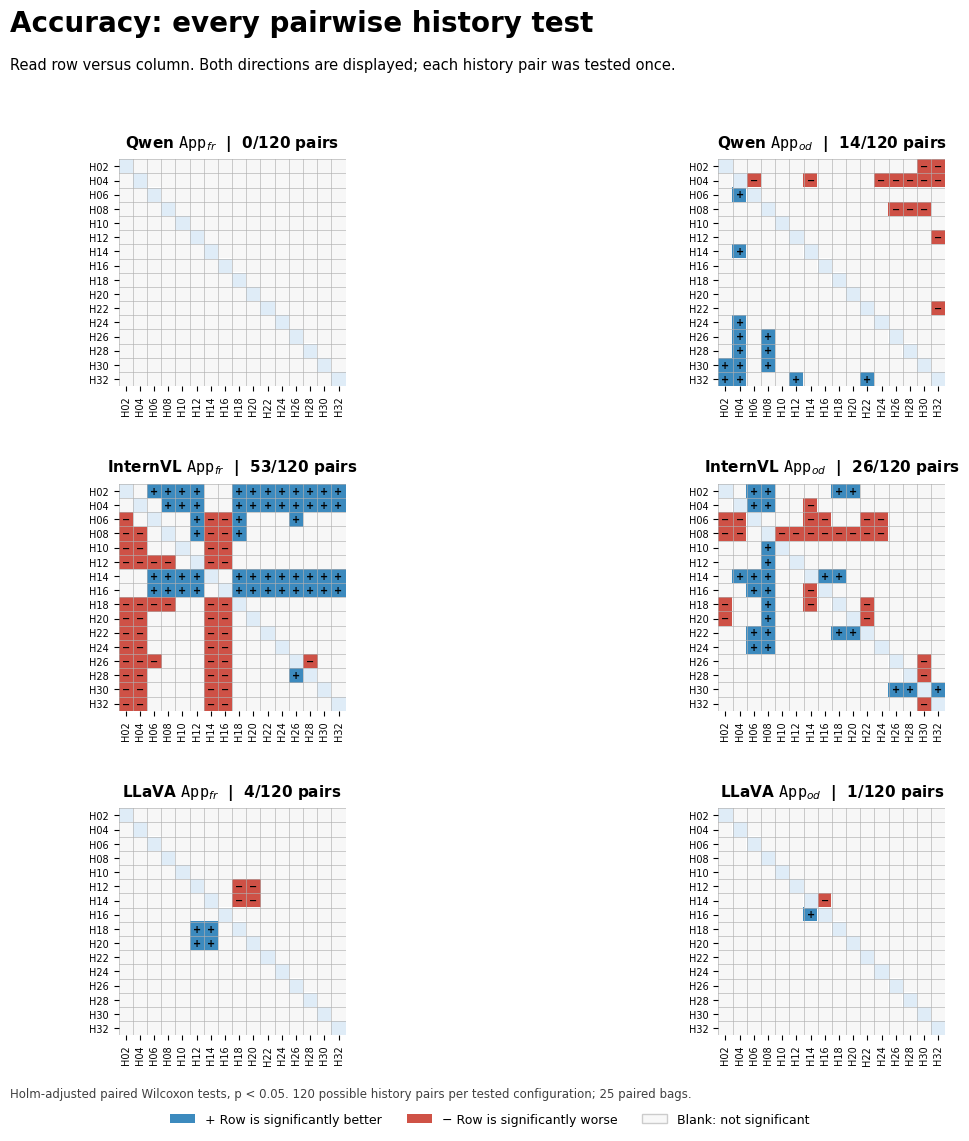

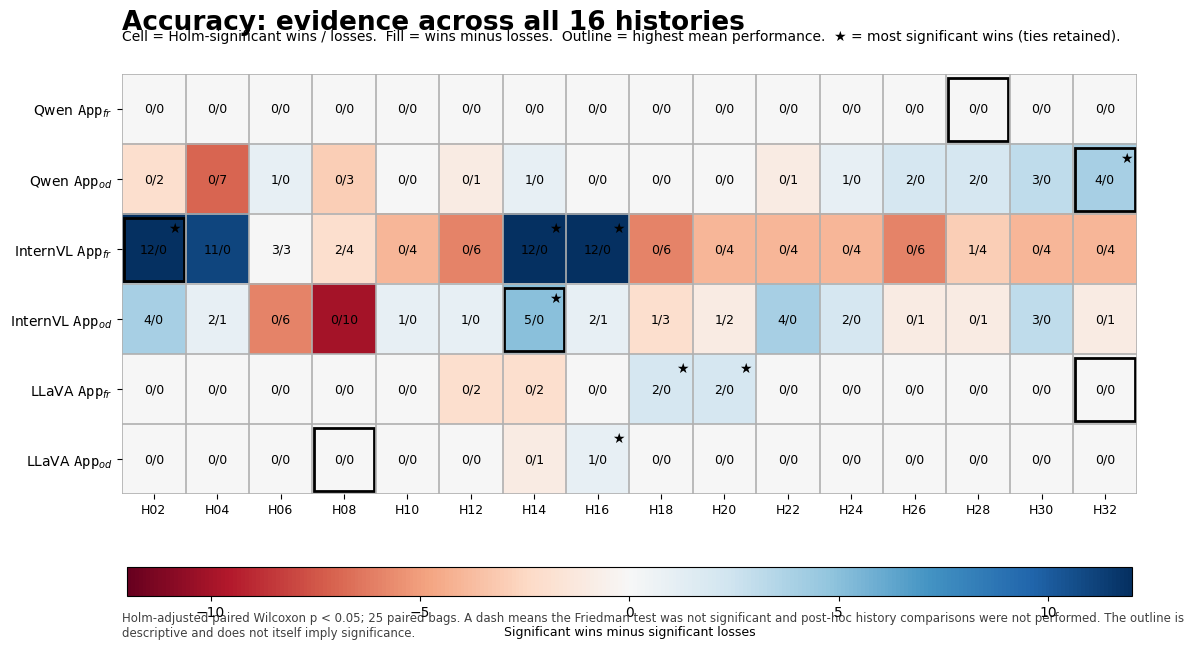

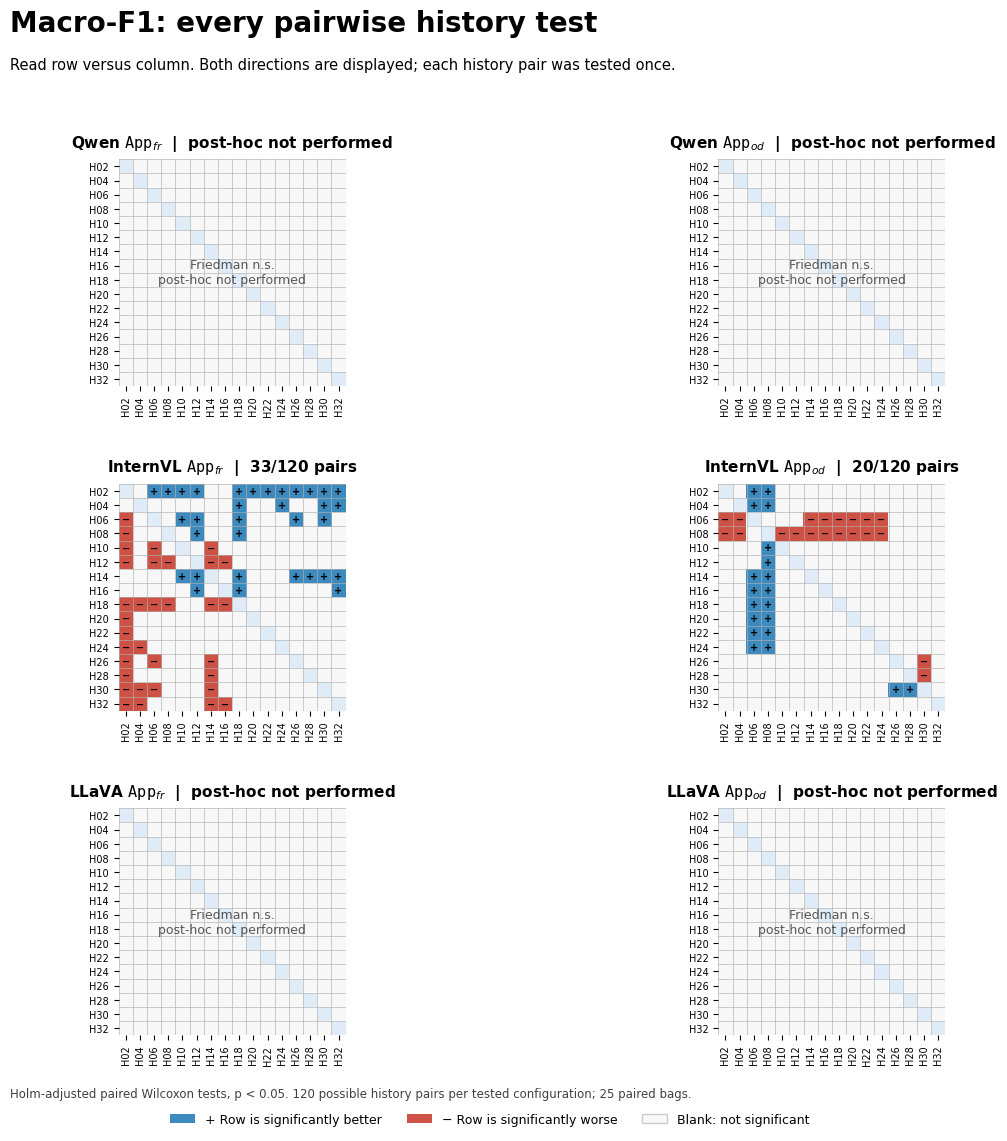

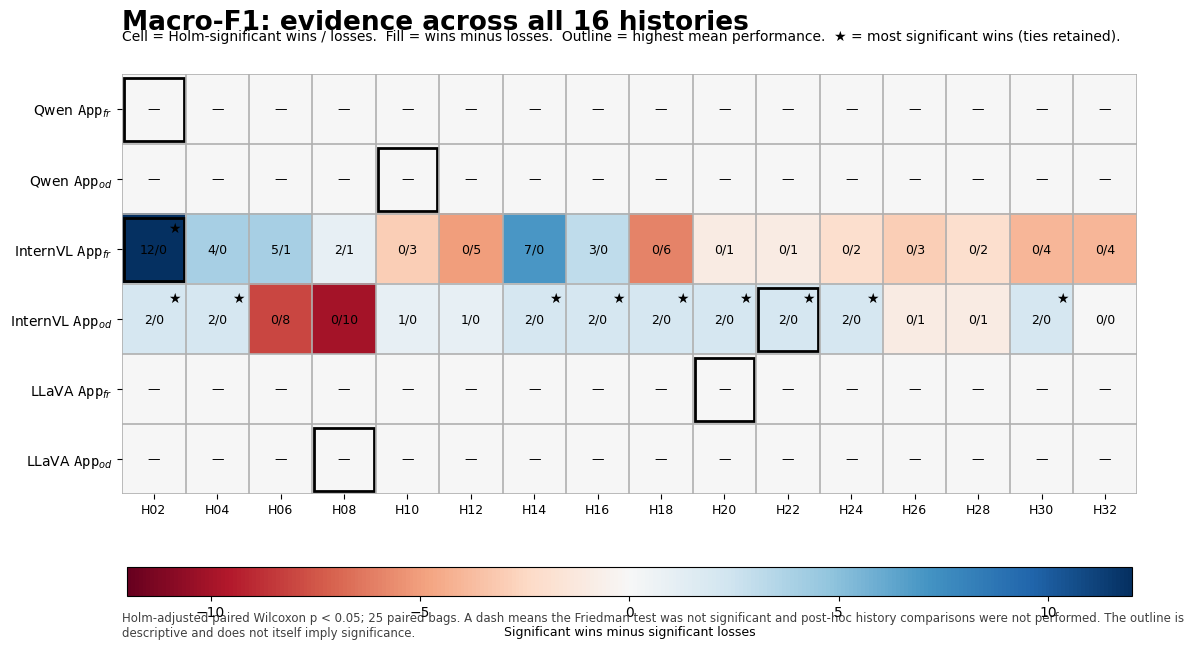

,Metric,Model,Approach,history,significant_wins,significant_losses,net_wins,mean_bag_value
0,Accuracy,InternVL,AppFr,H02,12,0,12,0.704604
1,Accuracy,InternVL,AppFr,H14,12,0,12,0.678818
2,Accuracy,InternVL,AppFr,H16,12,0,12,0.674931
3,Accuracy,InternVL,AppOd,H14,5,0,5,0.656826
4,Accuracy,LLaVA,AppFr,H18,2,0,2,0.691651
5,Accuracy,LLaVA,AppFr,H20,2,0,2,0.689656
6,Accuracy,LLaVA,AppOd,H16,1,0,1,0.667087
7,Accuracy,Qwen,AppOd,H32,4,0,4,0.764817
8,Macro-F1,InternVL,AppFr,H02,12,0,12,0.334410
9,Macro-F1,InternVL,AppOd,H22,2,0,2,0.311085



Saved figures to:
<HOME>/VLM_EW_Robot_Safety_DT/Analysis/Combined/rq3/figures


In [7]:
# ============================================================
# RQ3 — HISTORY-SELECTION FIGURES
# Generates pairwise matrices + history-evidence maps
# for BOTH Accuracy and Macro-F1
#
# Requires the previous notebook cells to have been run:
#   rq3_accuracy_profiles
#   rq3_accuracy_pairwise
#   rq3_accuracy_summary_detailed
#   rq3_macro_f1_profiles
#   rq3_macro_f1_pairwise
#   rq3_macro_f1_summary_detailed
#   MODELS, APPROACHES, HISTORIES, OUT
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Rectangle, Patch

FIG_DIR = OUT / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

MODEL_LABELS = {
    "qwen": "Qwen",
    "internvl": "InternVL",
    "llava": "LLaVA",
}

# Figure notation corresponding to \appFr{} and \appOd{} in the paper
APPROACH_LABELS = {
    "appfr": r"$\mathtt{App}_{fr}$",
    "appod": r"$\mathtt{App}_{od}$",
}

METRIC_LABELS = {
    "accuracy": "Accuracy",
    "macro_f1": "Macro-F1",
}


# ------------------------------------------------------------
# Helper: significant wins/losses for every history
# ------------------------------------------------------------
def build_history_evidence(pairwise_df, profiles_df):
    """
    Returns one row per model × approach × history with:
      - significant_wins
      - significant_losses
      - net_wins
      - mean_bag_value
      - is_mean_best
      - is_top_evidence

    Top evidence = history/histories having the largest number of
    Holm-significant pairwise wins. Ties are retained.
    """

    rows = []

    for model in MODELS:
        for approach in APPROACHES:

            family = pairwise_df[
                (pairwise_df["model"] == model) &
                (pairwise_df["approach"] == approach)
            ].copy()

            tests_performed = len(family) > 0

            sig = family[
                family["significant_holm"].fillna(False).astype(bool)
            ].copy()

            prof = profiles_df[
                (profiles_df["model"] == model) &
                (profiles_df["approach"] == approach)
            ].set_index("history")

            # descriptive best: highest bag-level mean
            mean_values = prof["mean_bag_value"].reindex(HISTORIES)
            max_mean = mean_values.max()

            # significant wins/losses
            wins = {h: 0 for h in HISTORIES}
            losses = {h: 0 for h in HISTORIES}

            for r in sig.itertuples(index=False):
                h1 = r.history_1
                h2 = r.history_2
                winner = r.significant_better_history

                if winner == h1:
                    wins[h1] += 1
                    losses[h2] += 1

                elif winner == h2:
                    wins[h2] += 1
                    losses[h1] += 1

            max_wins = max(wins.values()) if tests_performed else 0

            for h in HISTORIES:
                rows.append({
                    "model": model,
                    "approach": approach,
                    "history": h,
                    "tests_performed": tests_performed,
                    "significant_wins": wins[h],
                    "significant_losses": losses[h],
                    "net_wins": wins[h] - losses[h],
                    "mean_bag_value": mean_values.loc[h],
                    "is_mean_best": bool(
                        np.isclose(mean_values.loc[h], max_mean)
                    ),
                    # Only mark statistical best when at least one
                    # significant history comparison exists.
                    "is_top_evidence": bool(
                        max_wins > 0 and wins[h] == max_wins
                    ),
                })

    return pd.DataFrame(rows)


# ------------------------------------------------------------
# Figure 1: every pairwise history comparison
# ------------------------------------------------------------
def plot_pairwise_history_matrices(
    pairwise_df,
    metric,
    save=True,
):
    """
    3 × 2 grid:
      rows = models
      columns = approaches

    Matrix interpretation:
      + : row history significantly better than column history
      - : row history significantly worse than column history
      blank : no significant difference

    Both directions are displayed although each unordered pair
    was statistically tested only once.
    """

    metric_label = METRIC_LABELS[metric]
    n_hist = len(HISTORIES)

    # -1 = row worse, 0 = nonsignificant, +1 = row better
    cmap = ListedColormap([
        plt.get_cmap("RdBu")(0.18),
        plt.get_cmap("Greys")(0.06),
        plt.get_cmap("RdBu")(0.82),
    ])
    norm = BoundaryNorm([-1.5, -0.5, 0.5, 1.5], cmap.N)

    fig, axes = plt.subplots(
        len(MODELS),
        len(APPROACHES),
        figsize=(12, 12),
        constrained_layout=False,
    )

    fig.subplots_adjust(
        left=0.10,
        right=0.97,
        top=0.84,
        bottom=0.11,
        wspace=0.35,
        hspace=0.43,
    )

    fig.suptitle(
        f"{metric_label}: every pairwise history test",
        fontsize=20,
        fontweight="bold",
        x=0.10,
        ha="left",
        y=0.965,
    )

    fig.text(
        0.10,
        0.915,
        "Read row versus column. Both directions are displayed; "
        "each history pair was tested once.",
        fontsize=10.5,
        ha="left",
    )

    for i, model in enumerate(MODELS):
        for j, approach in enumerate(APPROACHES):

            ax = axes[i, j]

            family = pairwise_df[
                (pairwise_df["model"] == model) &
                (pairwise_df["approach"] == approach)
            ].copy()

            tests_performed = len(family) > 0
            significant = (
                family["significant_holm"].fillna(False).astype(bool).sum()
                if tests_performed else 0
            )

            matrix = np.zeros((n_hist, n_hist), dtype=float)

            # diagonal handled separately
            np.fill_diagonal(matrix, np.nan)

            if tests_performed:
                sig_family = family[
                    family["significant_holm"].fillna(False).astype(bool)
                ]

                for r in sig_family.itertuples(index=False):
                    i1 = HISTORIES.index(r.history_1)
                    i2 = HISTORIES.index(r.history_2)

                    if r.significant_better_history == r.history_1:
                        matrix[i1, i2] = 1
                        matrix[i2, i1] = -1

                    elif r.significant_better_history == r.history_2:
                        matrix[i1, i2] = -1
                        matrix[i2, i1] = 1

            masked = np.ma.masked_invalid(matrix)

            ax.imshow(
                masked,
                cmap=cmap,
                norm=norm,
                aspect="equal",
                interpolation="none",
            )

            # grid
            ax.set_xticks(
                np.arange(-0.5, n_hist, 1),
                minor=True,
            )
            ax.set_yticks(
                np.arange(-0.5, n_hist, 1),
                minor=True,
            )
            ax.grid(
                which="minor",
                linewidth=0.7,
                alpha=0.65,
            )
            ax.tick_params(which="minor", bottom=False, left=False)

            # diagonal
            for k in range(n_hist):
                ax.add_patch(
                    Rectangle(
                        (k - 0.5, k - 0.5),
                        1,
                        1,
                        facecolor=plt.get_cmap("Blues")(0.12),
                        edgecolor="none",
                    )
                )

            # + / - annotations
            for r in range(n_hist):
                for c in range(n_hist):
                    if r == c:
                        continue

                    if matrix[r, c] == 1:
                        ax.text(
                            c, r, "+",
                            ha="center",
                            va="center",
                            fontsize=7,
                            fontweight="bold",
                        )

                    elif matrix[r, c] == -1:
                        ax.text(
                            c, r, "−",
                            ha="center",
                            va="center",
                            fontsize=7,
                            fontweight="bold",
                        )

            # axes
            ax.set_xticks(range(n_hist))
            ax.set_xticklabels(
                HISTORIES,
                rotation=90,
                fontsize=7,
            )

            ax.set_yticks(range(n_hist))
            ax.set_yticklabels(
                HISTORIES,
                fontsize=7,
            )

            if tests_performed:
                title_right = f"{significant}/120 pairs"
            else:
                title_right = "post-hoc not performed"

            ax.set_title(
                f"{MODEL_LABELS[model]} "
                f"{APPROACH_LABELS[approach]}  |  {title_right}",
                fontsize=11,
                fontweight="bold",
                pad=9,
            )

            # If Friedman was not significant, make this explicit.
            if not tests_performed:
                ax.text(
                    7.5,
                    7.5,
                    "Friedman n.s.\n"
                    "post-hoc not performed",
                    ha="center",
                    va="center",
                    fontsize=9,
                    alpha=0.65,
                )

            for spine in ax.spines.values():
                spine.set_visible(False)

    legend_handles = [
        Patch(
            facecolor=plt.get_cmap("RdBu")(0.82),
            label="+ Row is significantly better",
        ),
        Patch(
            facecolor=plt.get_cmap("RdBu")(0.18),
            label="− Row is significantly worse",
        ),
        Patch(
            facecolor=plt.get_cmap("Greys")(0.06),
            edgecolor="0.8",
            label="Blank: not significant",
        ),
    ]

    fig.legend(
        handles=legend_handles,
        loc="lower center",
        ncol=3,
        frameon=False,
        fontsize=9,
        bbox_to_anchor=(0.5, 0.025),
    )

    fig.text(
        0.10,
        0.058,
        "Holm-adjusted paired Wilcoxon tests, p < 0.05. "
        "120 possible history pairs per tested configuration; "
        "25 paired bags.",
        fontsize=8.5,
        alpha=0.75,
        ha="left",
    )

    if save:
        stem = f"rq3_{metric}_all_pairwise_history_tests"

        fig.savefig(
            FIG_DIR / f"{stem}.png",
            dpi=400,
            bbox_inches="tight",
        )

        fig.savefig(
            FIG_DIR / f"{stem}.pdf",
            bbox_inches="tight",
        )

    plt.show()


# ------------------------------------------------------------
# Figure 2: compact evidence across all 16 histories
# ------------------------------------------------------------
def plot_history_evidence(
    pairwise_df,
    profiles_df,
    metric,
    save=True,
):
    """
    Compact history-selection figure.

    Cell:
        significant wins / significant losses

    Fill:
        significant wins - significant losses

    Outline:
        highest mean bag-level metric (descriptive maximum)

    ★:
        history/histories with the largest number of
        Holm-significant wins. Ties are retained.

    This separates:
        descriptive best
    from:
        strongest inferential support.
    """

    metric_label = METRIC_LABELS[metric]

    evidence = build_history_evidence(
        pairwise_df,
        profiles_df,
    )

    configurations = [
        (m, a)
        for m in MODELS
        for a in APPROACHES
    ]

    row_labels = [
        f"{MODEL_LABELS[m]} {APPROACH_LABELS[a]}"
        for m, a in configurations
    ]

    score = np.zeros(
        (len(configurations), len(HISTORIES)),
        dtype=float,
    )

    wins = np.zeros_like(score, dtype=int)
    losses = np.zeros_like(score, dtype=int)
    tested = np.zeros(len(configurations), dtype=bool)

    mean_best = np.zeros_like(score, dtype=bool)
    top_evidence = np.zeros_like(score, dtype=bool)

    for i, (model, approach) in enumerate(configurations):

        part = (
            evidence[
                (evidence["model"] == model) &
                (evidence["approach"] == approach)
            ]
            .set_index("history")
            .reindex(HISTORIES)
        )

        score[i, :] = part["net_wins"].to_numpy()
        wins[i, :] = part["significant_wins"].to_numpy()
        losses[i, :] = part["significant_losses"].to_numpy()

        tested[i] = bool(
            part["tests_performed"].iloc[0]
        )

        mean_best[i, :] = (
            part["is_mean_best"].to_numpy(dtype=bool)
        )

        top_evidence[i, :] = (
            part["is_top_evidence"].to_numpy(dtype=bool)
        )

    vmax = max(
        1,
        int(np.abs(score).max()),
    )

    fig, ax = plt.subplots(
        figsize=(12.5, 6.6),
    )

    im = ax.imshow(
        score,
        cmap="RdBu",
        vmin=-vmax,
        vmax=vmax,
        aspect="auto",
        interpolation="none",
    )

    ax.set_xticks(range(len(HISTORIES)))
    ax.set_xticklabels(
        HISTORIES,
        fontsize=9,
    )

    ax.set_yticks(range(len(configurations)))
    ax.set_yticklabels(
        row_labels,
        fontsize=10,
    )

    # cell boundaries
    ax.set_xticks(
        np.arange(-0.5, len(HISTORIES), 1),
        minor=True,
    )
    ax.set_yticks(
        np.arange(-0.5, len(configurations), 1),
        minor=True,
    )

    ax.grid(
        which="minor",
        linewidth=1.2,
    )

    ax.tick_params(
        which="minor",
        bottom=False,
        left=False,
    )

    # text + mean-best outlines + top-evidence star
    for i in range(len(configurations)):
        for j in range(len(HISTORIES)):

            if tested[i]:
                text = f"{wins[i, j]}/{losses[i, j]}"
            else:
                text = "—"

            ax.text(
                j,
                i,
                text,
                ha="center",
                va="center",
                fontsize=9,
            )

            # descriptive maximum
            if mean_best[i, j]:
                ax.add_patch(
                    Rectangle(
                        (j - 0.47, i - 0.45),
                        0.94,
                        0.90,
                        fill=False,
                        linewidth=2.0,
                    )
                )

            # strongest inferential history evidence
            if top_evidence[i, j]:
                ax.text(
                    j + 0.33,
                    i - 0.30,
                    "★",
                    ha="center",
                    va="center",
                    fontsize=10,
                    fontweight="bold",
                )

    ax.set_title(
        f"{metric_label}: evidence across all 16 histories",
        fontsize=19,
        fontweight="bold",
        loc="left",
        pad=32,
    )

    ax.text(
        0,
        1.08,
        "Cell = Holm-significant wins / losses.  "
        "Fill = wins minus losses.  "
        "Outline = highest mean performance.  "
        "★ = most significant wins (ties retained).",
        transform=ax.transAxes,
        fontsize=10,
        ha="left",
    )

    cbar = fig.colorbar(
        im,
        ax=ax,
        orientation="horizontal",
        fraction=0.055,
        pad=0.14,
        aspect=35,
    )

    cbar.set_label(
        "Significant wins minus significant losses",
        fontsize=9,
    )

    ax.text(
        0,
        -0.28,
        "Holm-adjusted paired Wilcoxon p < 0.05; "
        "25 paired bags. A dash means the Friedman test was not "
        "significant and post-hoc history comparisons were not performed. "
        "The outline is descriptive and does not itself imply significance.",
        transform=ax.transAxes,
        fontsize=8.5,
        alpha=0.75,
        ha="left",
        va="top",
        wrap=True,
    )

    for spine in ax.spines.values():
        spine.set_visible(False)

    plt.tight_layout()

    if save:
        stem = f"rq3_{metric}_history_evidence"

        fig.savefig(
            FIG_DIR / f"{stem}.png",
            dpi=400,
            bbox_inches="tight",
        )

        fig.savefig(
            FIG_DIR / f"{stem}.pdf",
            bbox_inches="tight",
        )

    plt.show()

    return evidence


# ============================================================
# ACCURACY
# ============================================================

plot_pairwise_history_matrices(
    rq3_accuracy_pairwise,
    metric="accuracy",
)

rq3_accuracy_history_evidence = plot_history_evidence(
    rq3_accuracy_pairwise,
    rq3_accuracy_profiles,
    metric="accuracy",
)


# ============================================================
# MACRO-F1
# ============================================================

plot_pairwise_history_matrices(
    rq3_macro_f1_pairwise,
    metric="macro_f1",
)

rq3_macro_f1_history_evidence = plot_history_evidence(
    rq3_macro_f1_pairwise,
    rq3_macro_f1_profiles,
    metric="macro_f1",
)


# ------------------------------------------------------------
# Optional: inspect the exact histories marked with ★
# ------------------------------------------------------------
best_history_evidence = pd.concat(
    [
        rq3_accuracy_history_evidence.assign(Metric="Accuracy"),
        rq3_macro_f1_history_evidence.assign(Metric="Macro-F1"),
    ],
    ignore_index=True,
)

best_history_evidence = best_history_evidence[
    best_history_evidence["is_top_evidence"]
].copy()

best_history_evidence["Model"] = (
    best_history_evidence["model"].map(MODEL_LABELS)
)

best_history_evidence["Approach"] = (
    best_history_evidence["approach"].map(
        {"appfr": "AppFr", "appod": "AppOd"}
    )
)

display(
    best_history_evidence[
        [
            "Metric",
            "Model",
            "Approach",
            "history",
            "significant_wins",
            "significant_losses",
            "net_wins",
            "mean_bag_value",
        ]
    ]
    .sort_values(
        ["Metric", "Model", "Approach",
         "significant_wins", "mean_bag_value"],
        ascending=[True, True, True, False, False],
    )
    .reset_index(drop=True)
)

print("\nSaved figures to:")
print(FIG_DIR)

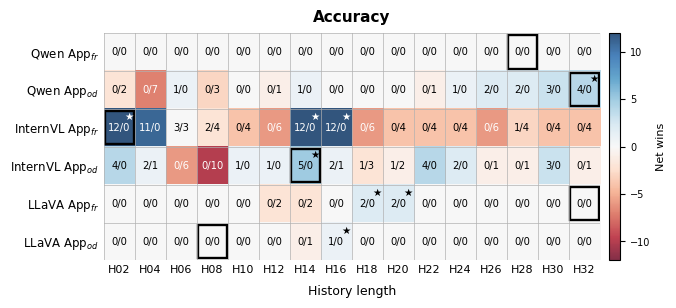

Saved:
<HOME>/VLM_EW_Robot_Safety_DT/Analysis/Combined/rq3/figures/rq3_accuracy_history_evidence.pdf
<HOME>/VLM_EW_Robot_Safety_DT/Analysis/Combined/rq3/figures/rq3_accuracy_history_evidence.png


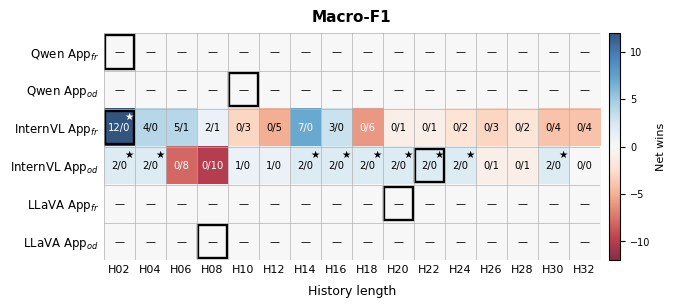

Saved:
<HOME>/VLM_EW_Robot_Safety_DT/Analysis/Combined/rq3/figures/rq3_macro_f1_history_evidence.pdf
<HOME>/VLM_EW_Robot_Safety_DT/Analysis/Combined/rq3/figures/rq3_macro_f1_history_evidence.png


In [8]:
# ============================================================
# RQ3 — PAPER FIGURES
# Two separate figures:
#   1. Accuracy history evidence
#   2. Macro-F1 history evidence
#
# Clean journal style:
# - no legend
# - no explanatory text inside figure
# - no global title
# - adaptive black/white cell text
# - PDF + high-resolution PNG
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.colors import TwoSlopeNorm

FIG_DIR = OUT / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

MODEL_LABELS = {
    "qwen": "Qwen",
    "internvl": "InternVL",
    "llava": "LLaVA",
}

APPROACH_LABELS = {
    "appfr": r"$\mathrm{App}_{fr}$",
    "appod": r"$\mathrm{App}_{od}$",
}

CONFIGS = [
    ("qwen", "appfr"),
    ("qwen", "appod"),
    ("internvl", "appfr"),
    ("internvl", "appod"),
    ("llava", "appfr"),
    ("llava", "appod"),
]


# ------------------------------------------------------------
# Build significant win/loss evidence
# ------------------------------------------------------------
def make_history_evidence(pairwise_df, profiles_df):

    rows = []

    for model, approach in CONFIGS:

        family = pairwise_df[
            (pairwise_df["model"] == model) &
            (pairwise_df["approach"] == approach)
        ].copy()

        posthoc_performed = len(family) > 0

        sig = family[
            family["significant_holm"]
            .fillna(False)
            .astype(bool)
        ].copy()

        wins = {h: 0 for h in HISTORIES}
        losses = {h: 0 for h in HISTORIES}

        for r in sig.itertuples(index=False):

            if r.significant_better_history == r.history_1:
                wins[r.history_1] += 1
                losses[r.history_2] += 1

            elif r.significant_better_history == r.history_2:
                wins[r.history_2] += 1
                losses[r.history_1] += 1

        profile = (
            profiles_df[
                (profiles_df["model"] == model) &
                (profiles_df["approach"] == approach)
            ]
            .set_index("history")
            .reindex(HISTORIES)
        )

        max_mean = profile["mean_bag_value"].max()
        max_wins = max(wins.values()) if posthoc_performed else 0

        for h in HISTORIES:

            rows.append({
                "model": model,
                "approach": approach,
                "history": h,

                "wins": wins[h],
                "losses": losses[h],
                "net": wins[h] - losses[h],

                "posthoc_performed": posthoc_performed,

                # Highest descriptive mean
                "highest_mean": np.isclose(
                    profile.loc[h, "mean_bag_value"],
                    max_mean
                ),

                # Highest number of significant wins
                "top_evidence": (
                    posthoc_performed
                    and max_wins > 0
                    and wins[h] == max_wins
                ),
            })

    return pd.DataFrame(rows)


accuracy_ev = make_history_evidence(
    rq3_accuracy_pairwise,
    rq3_accuracy_profiles,
)

macro_ev = make_history_evidence(
    rq3_macro_f1_pairwise,
    rq3_macro_f1_profiles,
)


# ------------------------------------------------------------
# Helper for readable text on colored cells
# ------------------------------------------------------------
def cell_text_color(value, vmax):
    """
    White text on strongly colored cells,
    black text on light/neutral cells.
    """
    if vmax == 0:
        return "black"

    strength = abs(value) / vmax

    if strength >= 0.48:
        return "white"

    return "black"


# ------------------------------------------------------------
# Plot ONE metric as ONE separate publication figure
# ------------------------------------------------------------
def plot_history_evidence_paper(
    evidence,
    metric_name,
    filename_stem,
):

    n_rows = len(CONFIGS)
    n_cols = len(HISTORIES)

    matrix = np.zeros(
        (n_rows, n_cols),
        dtype=float
    )

    # --------------------------------------------------------
    # Build net-win matrix
    # --------------------------------------------------------
    for i, (model, approach) in enumerate(CONFIGS):

        part = (
            evidence[
                (evidence["model"] == model) &
                (evidence["approach"] == approach)
            ]
            .set_index("history")
            .reindex(HISTORIES)
        )

        matrix[i, :] = part["net"].to_numpy()

    vmax = max(
        1,
        int(np.abs(matrix).max())
    )

    norm = TwoSlopeNorm(
        vmin=-vmax,
        vcenter=0,
        vmax=vmax
    )

    # Compact size suitable for journal insertion
    fig, ax = plt.subplots(
        figsize=(7.2, 3.25)
    )

    im = ax.imshow(
        matrix,
        cmap="RdBu",
        norm=norm,
        aspect="auto",
        interpolation="none",
        alpha=0.82,
    )

    # --------------------------------------------------------
    # Axis labels
    # --------------------------------------------------------
    ax.set_xticks(range(n_cols))
    ax.set_xticklabels(
        HISTORIES,
        fontsize=8
    )

    row_labels = [
        f"{MODEL_LABELS[m]} {APPROACH_LABELS[a]}"
        for m, a in CONFIGS
    ]

    ax.set_yticks(range(n_rows))
    ax.set_yticklabels(
        row_labels,
        fontsize=8.5
    )

    ax.set_xlabel(
        "History length",
        fontsize=9,
        labelpad=7
    )

    # Simple metric title only
    ax.set_title(
        metric_name,
        fontsize=11,
        fontweight="bold",
        pad=8
    )

    # --------------------------------------------------------
    # Cell boundaries
    # --------------------------------------------------------
    ax.set_xticks(
        np.arange(-0.5, n_cols, 1),
        minor=True
    )

    ax.set_yticks(
        np.arange(-0.5, n_rows, 1),
        minor=True
    )

    ax.grid(
        which="minor",
        linewidth=0.65,
        alpha=0.75,
    )

    ax.tick_params(
        which="minor",
        bottom=False,
        left=False
    )

    # --------------------------------------------------------
    # Cell labels + star + box
    # --------------------------------------------------------
    for i, (model, approach) in enumerate(CONFIGS):

        part = (
            evidence[
                (evidence["model"] == model) &
                (evidence["approach"] == approach)
            ]
            .set_index("history")
            .reindex(HISTORIES)
        )

        for j, history in enumerate(HISTORIES):

            row = part.loc[history]

            if not row["posthoc_performed"]:
                label = "—"
                txt_color = "black"

            else:
                label = (
                    f"{int(row['wins'])}/"
                    f"{int(row['losses'])}"
                )

                txt_color = cell_text_color(
                    matrix[i, j],
                    vmax
                )

            ax.text(
                j,
                i,
                label,
                ha="center",
                va="center",
                fontsize=7.2,
                color=txt_color,
                fontweight="medium",
            )

            # ------------------------------------------------
            # Star = most significant wins
            # ------------------------------------------------
            if row["top_evidence"]:

                star_color = cell_text_color(
                    matrix[i, j],
                    vmax
                )

                ax.text(
                    j + 0.33,
                    i - 0.29,
                    "★",
                    ha="center",
                    va="center",
                    fontsize=7.5,
                    color=star_color,
                    fontweight="bold",
                )

            # ------------------------------------------------
            # Box = highest mean performance
            # ------------------------------------------------
            if row["highest_mean"]:

                ax.add_patch(
                    Rectangle(
                        (j - 0.47, i - 0.44),
                        0.94,
                        0.88,
                        fill=False,
                        linewidth=1.7,
                        edgecolor="black",
                    )
                )

    # --------------------------------------------------------
    # Remove unnecessary frame
    # --------------------------------------------------------
    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.tick_params(
        axis="both",
        length=0
    )

    # --------------------------------------------------------
    # Compact colorbar only
    # No legend/text explanation
    # --------------------------------------------------------
    cbar = fig.colorbar(
        im,
        ax=ax,
        orientation="vertical",
        fraction=0.025,
        pad=0.018,
    )

    cbar.set_label(
        "Net wins",
        fontsize=8
    )

    cbar.ax.tick_params(
        labelsize=7
    )

    # Enough room; prevents text merging
    fig.subplots_adjust(
        left=0.20,
        right=0.92,
        top=0.88,
        bottom=0.18,
    )

    # --------------------------------------------------------
    # Save
    # --------------------------------------------------------
    pdf_path = FIG_DIR / f"{filename_stem}.pdf"
    png_path = FIG_DIR / f"{filename_stem}.png"

    fig.savefig(
        pdf_path,
        bbox_inches="tight"
    )

    fig.savefig(
        png_path,
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()
    plt.close(fig)

    print("Saved:")
    print(pdf_path)
    print(png_path)


# ============================================================
# FIGURE 1 — ACCURACY
# ============================================================

plot_history_evidence_paper(
    evidence=accuracy_ev,
    metric_name="Accuracy",
    filename_stem="rq3_accuracy_history_evidence"
)


# ============================================================
# FIGURE 2 — MACRO-F1
# ============================================================

plot_history_evidence_paper(
    evidence=macro_ev,
    metric_name="Macro-F1",
    filename_stem="rq3_macro_f1_history_evidence"
)

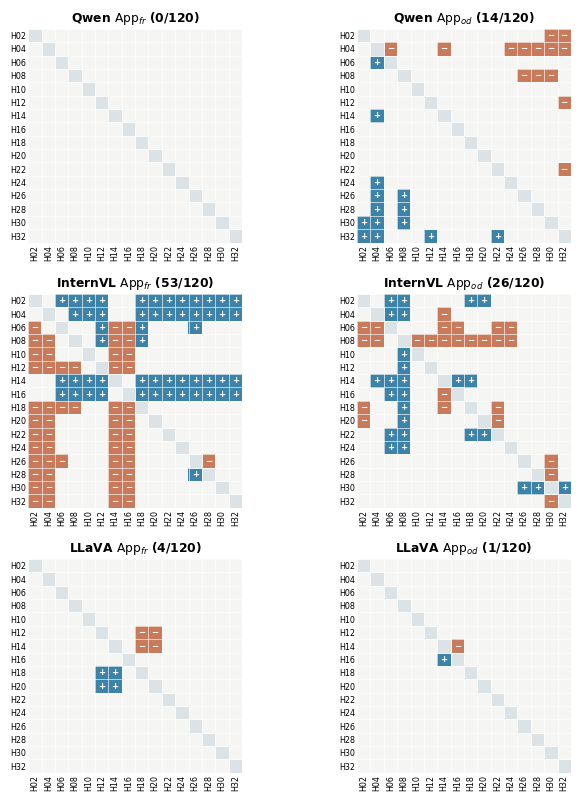

Saved PDF: <HOME>/VLM_EW_Robot_Safety_DT/Analysis/Combined/rq3/figures/rq3_accuracy_pairwise_history_matrix_paper.pdf
Saved PNG: <HOME>/VLM_EW_Robot_Safety_DT/Analysis/Combined/rq3/figures/rq3_accuracy_pairwise_history_matrix_paper.png


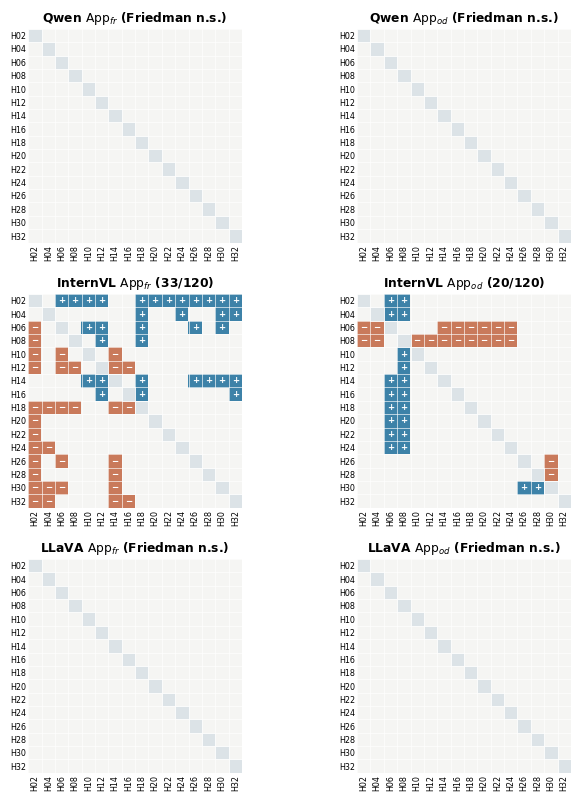

Saved PDF: <HOME>/VLM_EW_Robot_Safety_DT/Analysis/Combined/rq3/figures/rq3_macro_f1_pairwise_history_matrix_paper.pdf
Saved PNG: <HOME>/VLM_EW_Robot_Safety_DT/Analysis/Combined/rq3/figures/rq3_macro_f1_pairwise_history_matrix_paper.png


In [9]:
# ============================================================
# RQ3 — PUBLICATION PAIRWISE-HISTORY MATRICES
#
# Creates TWO separate paper figures:
#   1. Accuracy
#   2. Macro-F1
#
# Each figure:
#   3 models × 2 approaches
#   compact 3 × 2 layout
#   + = row history significantly better
#   − = row history significantly worse
#   blank = nonsignificant
#
# No figure-level legend/subtitle/footer.
# Explain symbols in the LaTeX caption.
#
# Requires:
#   rq3_accuracy_pairwise
#   rq3_accuracy_friedman
#   rq3_macro_f1_pairwise
#   rq3_macro_f1_friedman
#   MODELS, APPROACHES, HISTORIES, OUT
# ============================================================

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Rectangle

FIG_DIR = OUT / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

MODEL_LABELS = {
    "qwen": "Qwen",
    "internvl": "InternVL",
    "llava": "LLaVA",
}

APPROACH_LABELS = {
    "appfr": r"$\mathrm{App}_{fr}$",
    "appod": r"$\mathrm{App}_{od}$",
}


def plot_pairwise_history_figure(
    pairwise_df,
    friedman_df,
    metric_label,
    filename_stem,
):
    """
    Publication figure with six pairwise history matrices.

    Cell meaning:
        +  row history significantly better than column history
        −  row history significantly worse than column history
        blank = not significant

    Both matrix directions are displayed, although every unordered
    pair is statistically tested only once.
    """

    n_hist = len(HISTORIES)

    # --------------------------------------------------------
    # Discrete matrix:
    # -1 = row significantly worse
    #  0 = not significant
    # +1 = row significantly better
    # --------------------------------------------------------
    cmap = ListedColormap([
        "#C97A5B",   # worse
        "#F5F5F3",   # nonsignificant
        "#3D82A8",   # better
    ])

    norm = BoundaryNorm(
        [-1.5, -0.5, 0.5, 1.5],
        cmap.N
    )

    # --------------------------------------------------------
    # Compact paper layout
    # --------------------------------------------------------
    fig, axes = plt.subplots(
        3,
        2,
        figsize=(6.7, 8.0),
    )

    fig.subplots_adjust(
        left=0.095,
        right=0.995,
        top=0.985,
        bottom=0.055,
        wspace=0.20,
        hspace=0.24,
    )

    for i, model in enumerate(MODELS):
        for j, approach in enumerate(APPROACHES):

            ax = axes[i, j]

            # ------------------------------------------------
            # Omnibus result
            # ------------------------------------------------
            omni = friedman_df[
                (friedman_df["model"] == model) &
                (friedman_df["approach"] == approach)
            ]

            if len(omni) != 1:
                raise ValueError(
                    f"Expected one Friedman row for "
                    f"{model}/{approach}, found {len(omni)}."
                )

            friedman_sig = bool(
                omni.iloc[0]["significant_holm"]
            )

            # ------------------------------------------------
            # Pairwise family
            # ------------------------------------------------
            family = pairwise_df[
                (pairwise_df["model"] == model) &
                (pairwise_df["approach"] == approach)
            ].copy()

            sig = family[
                family["significant_holm"]
                .fillna(False)
                .astype(bool)
            ].copy()

            n_sig = len(sig)

            # ------------------------------------------------
            # Build full symmetric display matrix
            # ------------------------------------------------
            matrix = np.zeros(
                (n_hist, n_hist),
                dtype=float
            )

            for r in sig.itertuples(index=False):

                h1 = r.history_1
                h2 = r.history_2
                winner = r.significant_better_history

                a = HISTORIES.index(h1)
                b = HISTORIES.index(h2)

                if winner == h1:
                    matrix[a, b] = 1
                    matrix[b, a] = -1

                elif winner == h2:
                    matrix[a, b] = -1
                    matrix[b, a] = 1

            # ------------------------------------------------
            # Plot
            # ------------------------------------------------
            ax.imshow(
                matrix,
                cmap=cmap,
                norm=norm,
                aspect="equal",
                interpolation="none",
            )

            # diagonal — visually separate from nonsignificant
            for k in range(n_hist):
                ax.add_patch(
                    Rectangle(
                        (k - 0.5, k - 0.5),
                        1,
                        1,
                        facecolor="#DCE3E7",
                        edgecolor="white",
                        linewidth=0.4,
                    )
                )

            # ------------------------------------------------
            # Fine cell grid
            # ------------------------------------------------
            ax.set_xticks(
                np.arange(-0.5, n_hist, 1),
                minor=True
            )

            ax.set_yticks(
                np.arange(-0.5, n_hist, 1),
                minor=True
            )

            ax.grid(
                which="minor",
                color="white",
                linewidth=0.45,
            )

            ax.tick_params(
                which="minor",
                bottom=False,
                left=False,
            )

            # ------------------------------------------------
            # + / − symbols
            # ------------------------------------------------
            for row in range(n_hist):
                for col in range(n_hist):

                    if row == col:
                        continue

                    value = matrix[row, col]

                    if value == 1:
                        ax.text(
                            col,
                            row,
                            "+",
                            ha="center",
                            va="center",
                            fontsize=6.2,
                            fontweight="bold",
                            color="white",
                        )

                    elif value == -1:
                        ax.text(
                            col,
                            row,
                            "−",
                            ha="center",
                            va="center",
                            fontsize=6.2,
                            fontweight="bold",
                            color="white",
                        )

            # ------------------------------------------------
            # Axis ticks
            # ------------------------------------------------
            ax.set_xticks(range(n_hist))
            ax.set_xticklabels(
                HISTORIES,
                rotation=90,
                fontsize=5.8,
            )

            ax.set_yticks(range(n_hist))
            ax.set_yticklabels(
                HISTORIES,
                fontsize=5.8,
            )

            ax.tick_params(
                axis="both",
                length=0,
                pad=1.5,
            )

            # ------------------------------------------------
            # Compact panel title
            # ------------------------------------------------
            if friedman_sig:
                title_stat = f"{n_sig}/120"
            else:
                title_stat = "Friedman n.s."

            ax.set_title(
                f"{MODEL_LABELS[model]} "
                f"{APPROACH_LABELS[approach]} "
                f"({title_stat})",
                fontsize=8.8,
                fontweight="semibold",
                pad=5,
            )

            # ------------------------------------------------
            # No heavy frame
            # ------------------------------------------------
            for spine in ax.spines.values():
                spine.set_visible(False)

    # --------------------------------------------------------
    # Save vector PDF + high-resolution PNG
    # --------------------------------------------------------
    pdf_path = FIG_DIR / f"{filename_stem}.pdf"
    png_path = FIG_DIR / f"{filename_stem}.png"

    fig.savefig(
        pdf_path,
        bbox_inches="tight",
        pad_inches=0.03,
    )

    fig.savefig(
        png_path,
        dpi=600,
        bbox_inches="tight",
        pad_inches=0.03,
    )

    plt.show()
    plt.close(fig)

    print(f"Saved PDF: {pdf_path}")
    print(f"Saved PNG: {png_path}")


# ============================================================
# FIGURE 1 — ACCURACY
# ============================================================

plot_pairwise_history_figure(
    pairwise_df=rq3_accuracy_pairwise,
    friedman_df=rq3_accuracy_friedman,
    metric_label="Accuracy",
    filename_stem="rq3_accuracy_pairwise_history_matrix_paper",
)


# ============================================================
# FIGURE 2 — MACRO-F1
# ============================================================

plot_pairwise_history_figure(
    pairwise_df=rq3_macro_f1_pairwise,
    friedman_df=rq3_macro_f1_friedman,
    metric_label="Macro-F1",
    filename_stem="rq3_macro_f1_pairwise_history_matrix_paper",
)

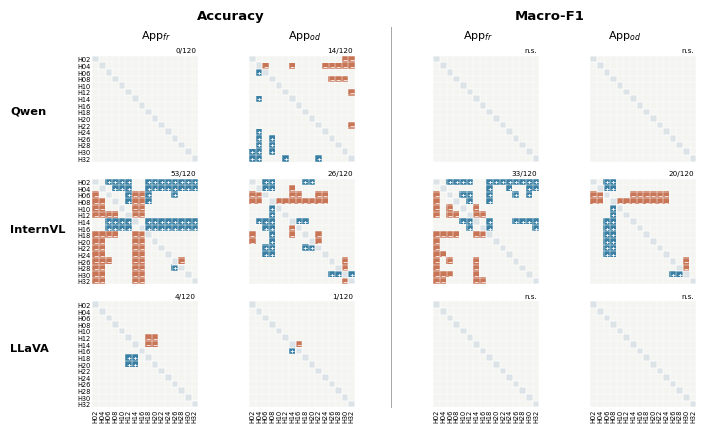

Saved:
<HOME>/VLM_EW_Robot_Safety_DT/Analysis/Combined/rq3/figures/rq3_accuracy_macro_f1_pairwise_compact.pdf
<HOME>/VLM_EW_Robot_Safety_DT/Analysis/Combined/rq3/figures/rq3_accuracy_macro_f1_pairwise_compact.png


In [10]:
# ============================================================
# RQ3 — SINGLE COMPACT PAPER FIGURE
#
# Layout:
#
#                 Accuracy                  Macro-F1
#             App_fr     App_od          App_fr     App_od
#
# Qwen        matrix     matrix          matrix     matrix
# InternVL    matrix     matrix          matrix     matrix
# LLaVA       matrix     matrix          matrix     matrix
#
# Designed for one full-width ACM/TOSEM figure occupying
# roughly half a page vertically.
#
# Requires:
#   rq3_accuracy_pairwise
#   rq3_accuracy_friedman
#   rq3_macro_f1_pairwise
#   rq3_macro_f1_friedman
#   HISTORIES, OUT
# ============================================================

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D

FIG_DIR = OUT / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

MODELS_PLOT = ["qwen", "internvl", "llava"]
APPROACHES_PLOT = ["appfr", "appod"]

MODEL_LABELS = {
    "qwen": "Qwen",
    "internvl": "InternVL",
    "llava": "LLaVA",
}

APPROACH_LABELS = {
    "appfr": r"$\mathrm{App}_{fr}$",
    "appod": r"$\mathrm{App}_{od}$",
}


# ------------------------------------------------------------
# Colors:
#   orange = row significantly worse
#   near-white = not significant
#   blue = row significantly better
# ------------------------------------------------------------
cmap = ListedColormap([
    "#C87556",
    "#F4F4F1",
    "#3A7FA3",
])

norm = BoundaryNorm(
    [-1.5, -0.5, 0.5, 1.5],
    cmap.N
)


# ------------------------------------------------------------
# Build one 16 × 16 history matrix
# ------------------------------------------------------------
def build_history_matrix(
    pairwise_df,
    friedman_df,
    model,
    approach,
):

    n = len(HISTORIES)

    matrix = np.zeros((n, n), dtype=float)

    omni = friedman_df[
        (friedman_df["model"] == model) &
        (friedman_df["approach"] == approach)
    ]

    if len(omni) != 1:
        raise ValueError(
            f"Expected one Friedman row for "
            f"{model}/{approach}, found {len(omni)}"
        )

    friedman_sig = bool(
        omni.iloc[0]["significant_holm"]
    )

    family = pairwise_df[
        (pairwise_df["model"] == model) &
        (pairwise_df["approach"] == approach)
    ].copy()

    # If omnibus Friedman is nonsignificant,
    # leave matrix blank and do not interpret post-hoc tests.
    if not friedman_sig:
        return matrix, False, 0

    sig = family[
        family["significant_holm"]
        .fillna(False)
        .astype(bool)
    ]

    for r in sig.itertuples(index=False):

        i = HISTORIES.index(r.history_1)
        j = HISTORIES.index(r.history_2)

        if r.significant_better_history == r.history_1:
            matrix[i, j] = 1
            matrix[j, i] = -1

        elif r.significant_better_history == r.history_2:
            matrix[i, j] = -1
            matrix[j, i] = 1

    return matrix, True, len(sig)


# ------------------------------------------------------------
# Draw one matrix
# ------------------------------------------------------------
def draw_matrix(
    ax,
    matrix,
    friedman_sig,
    n_sig,
    show_ylabels=False,
    show_xlabels=False,
):

    n = len(HISTORIES)

    ax.imshow(
        matrix,
        cmap=cmap,
        norm=norm,
        aspect="equal",
        interpolation="none",
    )

    # ----------------------------------------
    # Diagonal
    # ----------------------------------------
    for k in range(n):
        ax.add_patch(
            Rectangle(
                (k - 0.5, k - 0.5),
                1,
                1,
                facecolor="#DCE3E7",
                edgecolor="white",
                linewidth=0.35,
            )
        )

    # ----------------------------------------
    # Grid
    # ----------------------------------------
    ax.set_xticks(
        np.arange(-0.5, n, 1),
        minor=True
    )
    ax.set_yticks(
        np.arange(-0.5, n, 1),
        minor=True
    )

    ax.grid(
        which="minor",
        color="white",
        linewidth=0.35,
    )

    ax.tick_params(
        which="minor",
        bottom=False,
        left=False,
    )

    # ----------------------------------------
    # + / − symbols
    # ----------------------------------------
    if friedman_sig:

        for row in range(n):
            for col in range(n):

                if row == col:
                    continue

                if matrix[row, col] == 1:
                    ax.text(
                        col,
                        row,
                        "+",
                        ha="center",
                        va="center",
                        fontsize=4.6,
                        fontweight="bold",
                        color="white",
                    )

                elif matrix[row, col] == -1:
                    ax.text(
                        col,
                        row,
                        "−",
                        ha="center",
                        va="center",
                        fontsize=4.6,
                        fontweight="bold",
                        color="white",
                    )

    # ----------------------------------------
    # X labels only on bottom model row
    # ----------------------------------------
    ax.set_xticks(range(n))

    if show_xlabels:
        ax.set_xticklabels(
            HISTORIES,
            rotation=90,
            fontsize=4.8,
        )
    else:
        ax.set_xticklabels([])

    # ----------------------------------------
    # Y labels only on first Accuracy panel
    # ----------------------------------------
    ax.set_yticks(range(n))

    if show_ylabels:
        ax.set_yticklabels(
            HISTORIES,
            fontsize=4.8,
        )
    else:
        ax.set_yticklabels([])

    ax.tick_params(
        axis="both",
        length=0,
        pad=1,
    )

    # ----------------------------------------
    # Small statistical annotation
    # ----------------------------------------
    if friedman_sig:
        stat_text = f"{n_sig}/120"
    else:
        stat_text = "n.s."

    ax.text(
        0.98,
        1.025,
        stat_text,
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        fontsize=5.2,
    )

    # ----------------------------------------
    # Remove surrounding box
    # ----------------------------------------
    for spine in ax.spines.values():
        spine.set_visible(False)


# ============================================================
# FIGURE
# ============================================================

fig = plt.figure(
    figsize=(7.25, 4.45)
)

# 5 columns:
# Accuracy Fr | Accuracy Od | spacer | Macro Fr | Macro Od
gs = fig.add_gridspec(
    nrows=3,
    ncols=5,
    width_ratios=[1, 1, 0.12, 1, 1],
    height_ratios=[1, 1, 1],
    left=0.105,
    right=0.995,
    top=0.865,
    bottom=0.075,
    wspace=0.08,
    hspace=0.16,
)


# ------------------------------------------------------------
# Group headings
# ------------------------------------------------------------
fig.text(
    0.325,
    0.955,
    "Accuracy",
    ha="center",
    va="center",
    fontsize=9.5,
    fontweight="bold",
)

fig.text(
    0.765,
    0.955,
    "Macro-F1",
    ha="center",
    va="center",
    fontsize=9.5,
    fontweight="bold",
)


# ------------------------------------------------------------
# Approach headings
# ------------------------------------------------------------
fig.text(
    0.222,
    0.905,
    APPROACH_LABELS["appfr"],
    ha="center",
    fontsize=8,
)

fig.text(
    0.426,
    0.905,
    APPROACH_LABELS["appod"],
    ha="center",
    fontsize=8,
)

fig.text(
    0.665,
    0.905,
    APPROACH_LABELS["appfr"],
    ha="center",
    fontsize=8,
)

fig.text(
    0.868,
    0.905,
    APPROACH_LABELS["appod"],
    ha="center",
    fontsize=8,
)


# ------------------------------------------------------------
# Thin vertical separator
# ------------------------------------------------------------
fig.add_artist(
    Line2D(
        [0.545, 0.545],
        [0.075, 0.93],
        transform=fig.transFigure,
        linewidth=0.7,
        color="0.65",
    )
)


# ------------------------------------------------------------
# Plot all 12 matrices
# ------------------------------------------------------------
for row, model in enumerate(MODELS_PLOT):

    # Row/model label
    row_center = [0.742, 0.475, 0.207][row]

    fig.text(
        0.020,
        row_center,
        MODEL_LABELS[model],
        ha="left",
        va="center",
        fontsize=8.2,
        fontweight="semibold",
    )

    # ========================================================
    # ACCURACY — AppFr
    # ========================================================
    ax = fig.add_subplot(gs[row, 0])

    matrix, sig, n_sig = build_history_matrix(
        rq3_accuracy_pairwise,
        rq3_accuracy_friedman,
        model,
        "appfr",
    )

    draw_matrix(
        ax,
        matrix,
        sig,
        n_sig,
        show_ylabels=True,
        show_xlabels=(row == 2),
    )

    # ========================================================
    # ACCURACY — AppOd
    # ========================================================
    ax = fig.add_subplot(gs[row, 1])

    matrix, sig, n_sig = build_history_matrix(
        rq3_accuracy_pairwise,
        rq3_accuracy_friedman,
        model,
        "appod",
    )

    draw_matrix(
        ax,
        matrix,
        sig,
        n_sig,
        show_ylabels=False,
        show_xlabels=(row == 2),
    )

    # ========================================================
    # MACRO-F1 — AppFr
    # ========================================================
    ax = fig.add_subplot(gs[row, 3])

    matrix, sig, n_sig = build_history_matrix(
        rq3_macro_f1_pairwise,
        rq3_macro_f1_friedman,
        model,
        "appfr",
    )

    draw_matrix(
        ax,
        matrix,
        sig,
        n_sig,
        show_ylabels=False,
        show_xlabels=(row == 2),
    )

    # ========================================================
    # MACRO-F1 — AppOd
    # ========================================================
    ax = fig.add_subplot(gs[row, 4])

    matrix, sig, n_sig = build_history_matrix(
        rq3_macro_f1_pairwise,
        rq3_macro_f1_friedman,
        model,
        "appod",
    )

    draw_matrix(
        ax,
        matrix,
        sig,
        n_sig,
        show_ylabels=False,
        show_xlabels=(row == 2),
    )


# ------------------------------------------------------------
# Save
# ------------------------------------------------------------
pdf_path = (
    FIG_DIR /
    "rq3_accuracy_macro_f1_pairwise_compact.pdf"
)

png_path = (
    FIG_DIR /
    "rq3_accuracy_macro_f1_pairwise_compact.png"
)

fig.savefig(
    pdf_path,
    bbox_inches="tight",
    pad_inches=0.025,
)

fig.savefig(
    png_path,
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.025,
)

plt.show()
plt.close(fig)

print("Saved:")
print(pdf_path)
print(png_path)

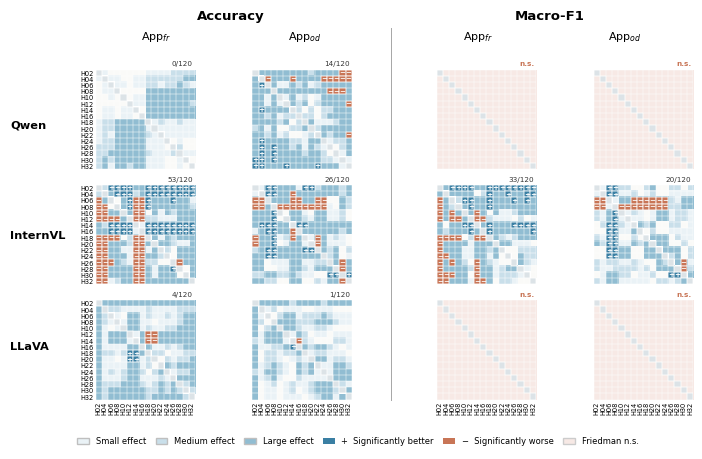

Saved PDF:
<HOME>/VLM_EW_Robot_Safety_DT/Analysis/Combined/rq3/figures/rq3_accuracy_macro_f1_pairwise_effectsize.pdf

Saved PNG:
<HOME>/VLM_EW_Robot_Safety_DT/Analysis/Combined/rq3/figures/rq3_accuracy_macro_f1_pairwise_effectsize.png


In [12]:
# ============================================================
# RQ3 — PAIRWISE HISTORY-LENGTH MATRICES
# Holm significance + matched-pairs rank-biserial effect size
#
# SIGNIFICANT:
#   Blue cell   + = row history significantly better
#   Red cell    − = row history significantly worse
#
# NON-SIGNIFICANT PAIRS:
#   Near-white  = |r_rb| < 0.11
#   Light blue  = Small  [0.11, 0.28)
#   Mid blue    = Medium [0.28, 0.43)
#   Deeper blue = Large  >= 0.43
#
# Friedman n.s. panel:
#   very light warm/red background
#
# Saves:
#   PDF = vector publication figure
#   PNG = 600 dpi
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Rectangle, Patch
from matplotlib.lines import Line2D


# ============================================================
# OUTPUT
# ============================================================

FIG_DIR = OUT / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

MODELS_PLOT = ["qwen", "internvl", "llava"]

MODEL_LABELS = {
    "qwen": "Qwen",
    "internvl": "InternVL",
    "llava": "LLaVA",
}

APPROACH_LABELS = {
    "appfr": r"$\mathrm{App}_{fr}$",
    "appod": r"$\mathrm{App}_{od}$",
}


# ============================================================
# COLORS
# ============================================================

# ------------------------------------------------------------
# Non-significant cells:
# color represents EFFECT-SIZE MAGNITUDE
# ------------------------------------------------------------

COLOR_NEGLIGIBLE = "#FAFAF8"   # |r| < 0.11
COLOR_SMALL      = "#EAF2F6"   # small
COLOR_MEDIUM     = "#C9DFEA"   # medium
COLOR_LARGE      = "#91BDD2"   # large

# ------------------------------------------------------------
# Statistically significant cells
# ------------------------------------------------------------

COLOR_SIG_BETTER = "#3A7FA3"   # blue
COLOR_SIG_WORSE  = "#C87556"   # muted red/orange

# ------------------------------------------------------------
# Other
# ------------------------------------------------------------

COLOR_FRIEDMAN_NS = "#F7E9E5"   # very light warm red
COLOR_DIAGONAL    = "#DCE3E7"
COLOR_GRID        = "#FFFFFF"


# ============================================================
# EFFECT SIZE
# ============================================================

def effect_category(r_rb):
    """
    Matched-pairs rank-biserial effect size.

    Returns
    -------
    0 : |r_rb| < 0.11
    1 : Small   0.11 <= |r_rb| < 0.28
    2 : Medium  0.28 <= |r_rb| < 0.43
    3 : Large   |r_rb| >= 0.43
    """

    a = abs(float(r_rb))

    if a >= 0.43:
        return 3
    elif a >= 0.28:
        return 2
    elif a >= 0.11:
        return 1
    else:
        return 0


EFFECT_COLORS = [
    COLOR_NEGLIGIBLE,
    COLOR_SMALL,
    COLOR_MEDIUM,
    COLOR_LARGE,
]

effect_cmap = ListedColormap(EFFECT_COLORS)

effect_norm = BoundaryNorm(
    [-0.5, 0.5, 1.5, 2.5, 3.5],
    effect_cmap.N
)


# ============================================================
# BUILD ONE HISTORY MATRIX
# ============================================================

def build_history_matrices(
    pairwise_df,
    friedman_df,
    model,
    approach,
):

    n = len(HISTORIES)

    # Effect-size category
    effect_matrix = np.full(
        (n, n),
        np.nan,
        dtype=float
    )

    # Significance direction
    #
    #  1 = row significantly better
    # -1 = row significantly worse
    #  0 = not significant
    sig_matrix = np.zeros(
        (n, n),
        dtype=int
    )

    # --------------------------------------------------------
    # Friedman
    # --------------------------------------------------------

    omni = friedman_df[
        (friedman_df["model"] == model) &
        (friedman_df["approach"] == approach)
    ]

    if len(omni) != 1:
        raise ValueError(
            f"Expected one Friedman result for "
            f"{model}/{approach}, found {len(omni)}."
        )

    friedman_sig = bool(
        omni.iloc[0]["significant_holm"]
    )

    # --------------------------------------------------------
    # IMPORTANT:
    # No post-hoc interpretation if Friedman is nonsignificant
    # --------------------------------------------------------

    if not friedman_sig:
        return (
            effect_matrix,
            sig_matrix,
            False,
            0
        )

    # --------------------------------------------------------
    # Pairwise Wilcoxon results
    # --------------------------------------------------------

    family = pairwise_df[
        (pairwise_df["model"] == model) &
        (pairwise_df["approach"] == approach)
    ].copy()

    if len(family) != 120:
        print(
            f"Warning: {model}/{approach}: "
            f"{len(family)} pairwise rows; expected 120."
        )

    n_sig = int(
        family["significant_holm"]
        .fillna(False)
        .astype(bool)
        .sum()
    )

    # --------------------------------------------------------
    # Fill matrices
    # --------------------------------------------------------

    for r in family.itertuples(index=False):

        h1 = r.history_1
        h2 = r.history_2

        i = HISTORIES.index(h1)
        j = HISTORIES.index(h2)

        r_rb = r.rank_biserial_h1_minus_h2

        if pd.isna(r_rb):
            continue

        # ----------------------------------------------------
        # Effect-size magnitude
        # symmetric for H1/H2 pair
        # ----------------------------------------------------

        category = effect_category(r_rb)

        effect_matrix[i, j] = category
        effect_matrix[j, i] = category

        # ----------------------------------------------------
        # Statistical significance
        # ----------------------------------------------------

        is_sig = bool(r.significant_holm)

        if not is_sig:
            continue

        better = r.significant_better_history

        if better == h1:

            sig_matrix[i, j] = 1
            sig_matrix[j, i] = -1

        elif better == h2:

            sig_matrix[i, j] = -1
            sig_matrix[j, i] = 1


    return (
        effect_matrix,
        sig_matrix,
        True,
        n_sig
    )


# ============================================================
# DRAW ONE MATRIX
# ============================================================

def draw_matrix(
    ax,
    effect_matrix,
    sig_matrix,
    friedman_sig,
    n_sig,
    show_ylabels=False,
    show_xlabels=False,
):

    n = len(HISTORIES)

    # --------------------------------------------------------
    # Friedman nonsignificant panel
    # --------------------------------------------------------

    if not friedman_sig:

        ns_matrix = np.ones((n, n))

        ax.imshow(
            ns_matrix,
            cmap=ListedColormap([COLOR_FRIEDMAN_NS]),
            aspect="equal",
            interpolation="none",
        )

    else:

        # ----------------------------------------------------
        # Base = effect-size shading
        # ----------------------------------------------------

        ax.imshow(
            effect_matrix,
            cmap=effect_cmap,
            norm=effect_norm,
            aspect="equal",
            interpolation="none",
        )

    # --------------------------------------------------------
    # Override significant cells with original
    # blue / reddish colors
    # --------------------------------------------------------

    if friedman_sig:

        for row in range(n):

            for col in range(n):

                if row == col:
                    continue

                direction = sig_matrix[row, col]

                # --------------------------------------------
                # Significant BETTER
                # --------------------------------------------

                if direction == 1:

                    ax.add_patch(
                        Rectangle(
                            (col - 0.5, row - 0.5),
                            1,
                            1,
                            facecolor=COLOR_SIG_BETTER,
                            edgecolor=COLOR_GRID,
                            linewidth=0.35,
                        )
                    )

                    ax.text(
                        col,
                        row,
                        "+",
                        ha="center",
                        va="center",
                        fontsize=5.1,
                        fontweight="bold",
                        color="white",
                    )

                # --------------------------------------------
                # Significant WORSE
                # --------------------------------------------

                elif direction == -1:

                    ax.add_patch(
                        Rectangle(
                            (col - 0.5, row - 0.5),
                            1,
                            1,
                            facecolor=COLOR_SIG_WORSE,
                            edgecolor=COLOR_GRID,
                            linewidth=0.35,
                        )
                    )

                    ax.text(
                        col,
                        row,
                        "−",
                        ha="center",
                        va="center",
                        fontsize=5.1,
                        fontweight="bold",
                        color="white",
                    )


    # ========================================================
    # DIAGONAL
    # ========================================================

    for k in range(n):

        ax.add_patch(
            Rectangle(
                (k - 0.5, k - 0.5),
                1,
                1,
                facecolor=COLOR_DIAGONAL,
                edgecolor=COLOR_GRID,
                linewidth=0.35,
            )
        )


    # ========================================================
    # GRID
    # ========================================================

    ax.set_xticks(
        np.arange(-0.5, n, 1),
        minor=True
    )

    ax.set_yticks(
        np.arange(-0.5, n, 1),
        minor=True
    )

    ax.grid(
        which="minor",
        color=COLOR_GRID,
        linewidth=0.35,
    )

    ax.tick_params(
        which="minor",
        bottom=False,
        left=False,
    )


    # ========================================================
    # HISTORY LABELS
    # ========================================================

    ax.set_xticks(range(n))

    if show_xlabels:

        ax.set_xticklabels(
            HISTORIES,
            rotation=90,
            fontsize=4.8,
        )

    else:

        ax.set_xticklabels([])


    ax.set_yticks(range(n))

    if show_ylabels:

        ax.set_yticklabels(
            HISTORIES,
            fontsize=4.8,
        )

    else:

        ax.set_yticklabels([])


    ax.tick_params(
        axis="both",
        length=0,
        pad=1,
    )


    # ========================================================
    # SIGNIFICANT-PAIR COUNT
    # ========================================================

    if friedman_sig:

        stat_text = f"{n_sig}/120"

        stat_color = "0.20"

    else:

        stat_text = "n.s."

        stat_color = COLOR_SIG_WORSE


    ax.text(
        0.98,
        1.025,
        stat_text,
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        fontsize=5.2,
        fontweight="semibold"
        if not friedman_sig
        else "normal",
        color=stat_color,
    )


    # ========================================================
    # REMOVE FRAME
    # ========================================================

    for spine in ax.spines.values():
        spine.set_visible(False)


# ============================================================
# FIGURE
# ============================================================

fig = plt.figure(
    figsize=(7.25, 4.65)
)


# Accuracy-Fr | Accuracy-Od | gap |
# MacroF1-Fr | MacroF1-Od

gs = fig.add_gridspec(

    nrows=3,

    ncols=5,

    width_ratios=[
        1,
        1,
        0.12,
        1,
        1
    ],

    height_ratios=[
        1,
        1,
        1
    ],

    left=0.105,
    right=0.995,

    top=0.84,
    bottom=0.13,

    wspace=0.08,
    hspace=0.16,
)


# ============================================================
# MAIN HEADINGS
# ============================================================

fig.text(
    0.325,
    0.955,
    "Accuracy",
    ha="center",
    va="center",
    fontsize=9.5,
    fontweight="bold",
)

fig.text(
    0.765,
    0.955,
    "Macro-F1",
    ha="center",
    va="center",
    fontsize=9.5,
    fontweight="bold",
)


# ============================================================
# APPROACH HEADINGS
# ============================================================

fig.text(
    0.222,
    0.905,
    APPROACH_LABELS["appfr"],
    ha="center",
    fontsize=8,
)

fig.text(
    0.426,
    0.905,
    APPROACH_LABELS["appod"],
    ha="center",
    fontsize=8,
)

fig.text(
    0.665,
    0.905,
    APPROACH_LABELS["appfr"],
    ha="center",
    fontsize=8,
)

fig.text(
    0.868,
    0.905,
    APPROACH_LABELS["appod"],
    ha="center",
    fontsize=8,
)


# ============================================================
# SEPARATOR
# ============================================================

fig.add_artist(

    Line2D(

        [0.545, 0.545],

        [0.13, 0.93],

        transform=fig.transFigure,

        linewidth=0.7,

        color="0.65",
    )
)


# ============================================================
# DRAW ALL 12 PANELS
# ============================================================

for row, model in enumerate(MODELS_PLOT):

    row_center = [
        0.720,
        0.482,
        0.244
    ][row]

    fig.text(
        0.020,
        row_center,
        MODEL_LABELS[model],
        ha="left",
        va="center",
        fontsize=8.2,
        fontweight="semibold",
    )


    # --------------------------------------------------------
    # Accuracy — AppFr
    # --------------------------------------------------------

    ax = fig.add_subplot(
        gs[row, 0]
    )

    e, s, fsig, n_sig = build_history_matrices(
        rq3_accuracy_pairwise,
        rq3_accuracy_friedman,
        model,
        "appfr",
    )

    draw_matrix(
        ax,
        e,
        s,
        fsig,
        n_sig,
        show_ylabels=True,
        show_xlabels=(row == 2),
    )


    # --------------------------------------------------------
    # Accuracy — AppOd
    # --------------------------------------------------------

    ax = fig.add_subplot(
        gs[row, 1]
    )

    e, s, fsig, n_sig = build_history_matrices(
        rq3_accuracy_pairwise,
        rq3_accuracy_friedman,
        model,
        "appod",
    )

    draw_matrix(
        ax,
        e,
        s,
        fsig,
        n_sig,
        show_ylabels=False,
        show_xlabels=(row == 2),
    )


    # --------------------------------------------------------
    # Macro-F1 — AppFr
    # --------------------------------------------------------

    ax = fig.add_subplot(
        gs[row, 3]
    )

    e, s, fsig, n_sig = build_history_matrices(
        rq3_macro_f1_pairwise,
        rq3_macro_f1_friedman,
        model,
        "appfr",
    )

    draw_matrix(
        ax,
        e,
        s,
        fsig,
        n_sig,
        show_ylabels=False,
        show_xlabels=(row == 2),
    )


    # --------------------------------------------------------
    # Macro-F1 — AppOd
    # --------------------------------------------------------

    ax = fig.add_subplot(
        gs[row, 4]
    )

    e, s, fsig, n_sig = build_history_matrices(
        rq3_macro_f1_pairwise,
        rq3_macro_f1_friedman,
        model,
        "appod",
    )

    draw_matrix(
        ax,
        e,
        s,
        fsig,
        n_sig,
        show_ylabels=False,
        show_xlabels=(row == 2),
    )


# ============================================================
# LEGEND
# ============================================================

legend_handles = [

    # Effect magnitudes

    Patch(
        facecolor=COLOR_SMALL,
        edgecolor="0.75",
        label="Small effect",
    ),

    Patch(
        facecolor=COLOR_MEDIUM,
        edgecolor="0.75",
        label="Medium effect",
    ),

    Patch(
        facecolor=COLOR_LARGE,
        edgecolor="0.75",
        label="Large effect",
    ),

    # Significant

    Patch(
        facecolor=COLOR_SIG_BETTER,
        edgecolor="none",
        label="+  Significantly better",
    ),

    Patch(
        facecolor=COLOR_SIG_WORSE,
        edgecolor="none",
        label="−  Significantly worse",
    ),

    # Friedman n.s.

    Patch(
        facecolor=COLOR_FRIEDMAN_NS,
        edgecolor="0.80",
        label="Friedman n.s.",
    ),
]


fig.legend(

    handles=legend_handles,

    loc="lower center",

    bbox_to_anchor=(
        0.5,
        0.015
    ),

    ncol=6,

    frameon=False,

    fontsize=6.0,

    handlelength=1.4,

    columnspacing=1.15,
)


# ============================================================
# SAVE — PDF IS VECTOR
# ============================================================

pdf_path = (
    FIG_DIR /
    "rq3_accuracy_macro_f1_pairwise_effectsize.pdf"
)

png_path = (
    FIG_DIR /
    "rq3_accuracy_macro_f1_pairwise_effectsize.png"
)


fig.savefig(
    pdf_path,
    format="pdf",
    bbox_inches="tight",
    pad_inches=0.025,
)


fig.savefig(
    png_path,
    format="png",
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.025,
)


plt.show()

plt.close(fig)


print("Saved PDF:")
print(pdf_path)

print("\nSaved PNG:")
print(png_path)